In [1]:
# =============================================================================
# BREAST LESION SEGMENTATION & CLASSIFICATION  ─  Swin-T UNet Pipeline
# Model  : Swin Transformer Tiny (encoder) + UNet decoder  (Multi-Task)
# Tasks  : Classification (benign / malignant / normal)  +  Segmentation
# Dataset: Combined BUSI + BUS-UCLM  (~1400 images)
# Target : > 85 % Cls Accuracy  │  > 0.85 Dice  (with augmentation)
# Platform: Kaggle  (T4 / P100 GPU)
# =============================================================================

# ============================================================
# CELL 1 — Install Required Libraries
# ============================================================
import subprocess, sys

pkgs = [
    "segmentation-models-pytorch>=0.3.3",
    "albumentations>=1.3.1",
    "timm>=0.9.12",          # needed for Swin-T encoder in SMP
    "torchmetrics>=1.2.0",
    "mlxtend",
    "einops",
]
subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkgs, check=False)
print("✔ All libraries ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.9 MB/s eta 0:00:00
✔ All libraries ready.


In [2]:
# ============================================================
# CELL 2 — Import All Libraries
# ============================================================
import os, glob, time, random, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import (
    CosineAnnealingWarmRestarts, OneCycleLR,
    ReduceLROnPlateau, CosineAnnealingLR, LinearLR, SequentialLR
)
from torch.cuda.amp import GradScaler, autocast

import torchvision.transforms.functional as TF
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import timm

warnings.filterwarnings("ignore")
print(f"PyTorch   : {torch.__version__}")
print(f"SMP       : {smp.__version__}")
print(f"timm      : {timm.__version__}")
print(f"CUDA avail: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU       : {torch.cuda.get_device_name(0)}")


PyTorch   : 2.10.0+cu128
SMP       : 0.5.0
timm      : 1.0.25
CUDA avail: True
GPU       : Tesla T4


In [3]:
# ============================================================
# CELL 3 — Configuration & Hyperparameters
# ============================================================

class CFG:
    # ── Dataset ─────────────────────────────────────────────
    DATA_ROOT   = "/kaggle/input/datasets/arittrosahadhrubo/breast-lesion-segmentation-d1/combined_dataset"
    CLASSES     = ["benign", "malignant", "normal"]
    NUM_CLASSES = 3

    # ── Image ───────────────────────────────────────────────
    # Swin-T pretrained at 224×224 (window_size=7; 224/4/7 = 8 tokens — exact fit)
    IMG_SIZE    = 224
    CHANNELS    = 3

    # ── Reproducibility ─────────────────────────────────────
    SEED        = 42

    # ── Training schedule ───────────────────────────────────
    EPOCHS           = 80    # upper bound; EarlyStopping controls actual end
    BATCH_SIZE       = 8     # Swin-T needs more VRAM; keep small for T4
    ACCUM_STEPS      = 2     # gradient accumulation → effective batch = 16
    NUM_WORKERS      = 2
    PIN_MEMORY       = True
    VAL_SPLIT        = 0.15
    TEST_SPLIT       = 0.15

    # ── Optimiser ───────────────────────────────────────────
    LR               = 2e-4
    ENCODER_LR_MULT  = 0.1   # encoder LR = LR × 0.1  (fine-tuning)
    WEIGHT_DECAY     = 1e-4
    GRAD_CLIP        = 1.0

    # ── Scheduler (warmup + cosine) ─────────────────────────
    WARMUP_EPOCHS    = 5
    T_MAX            = 75    # cosine period

    # ── Early stopping / LR plateau ─────────────────────────
    EARLY_STOP_PAT   = 15
    LR_PAT           = 6
    LR_FACTOR        = 0.5
    MIN_LR           = 1e-7

    # ── Loss weights ────────────────────────────────────────
    SEG_WEIGHT       = 0.55
    CLS_WEIGHT       = 0.45

    # ── Model ───────────────────────────────────────────────
    ENCODER          = "tu-swin_tiny_patch4_window7_224"
    ENC_WEIGHTS      = "imagenet"
    DROPOUT          = 0.40

    # ── Runtime ─────────────────────────────────────────────
    DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"
    SAVE_DIR         = "/kaggle/working/checkpoints"
    AMP              = True   # mixed-precision


os.makedirs(CFG.SAVE_DIR, exist_ok=True)

def seed_everything(seed=CFG.SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

seed_everything()
print(f"Device  : {CFG.DEVICE}")
print(f"Encoder : {CFG.ENCODER}")
print(f"Img size: {CFG.IMG_SIZE}×{CFG.IMG_SIZE}")
print(f"Eff. batch: {CFG.BATCH_SIZE * CFG.ACCUM_STEPS}")


Device  : cuda
Encoder : tu-swin_tiny_patch4_window7_224
Img size: 224×224
Eff. batch: 16


Total samples       : 1467
Samples with masks  : 1467

Class distribution:
class_name
normal       729
benign       477
malignant    261


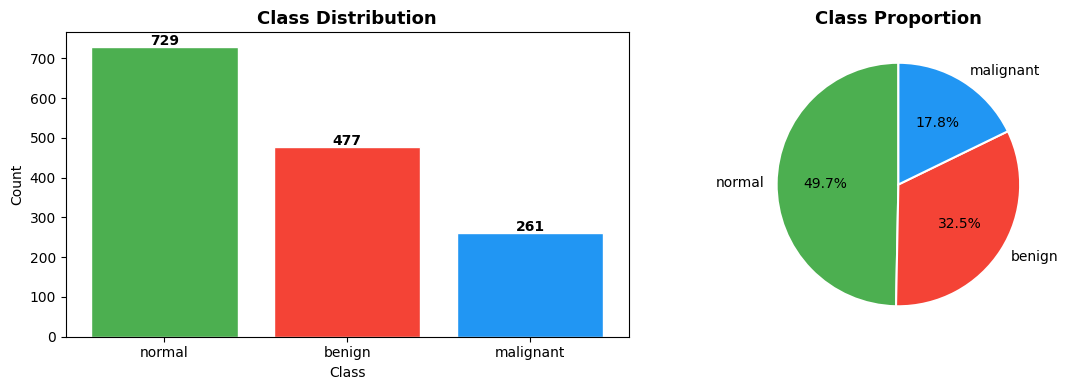

Train : 1026  |  Val :  220  |  Test :  221
  Train: {'normal': np.int64(510), 'benign': np.int64(333), 'malignant': np.int64(183)}
  Val: {'normal': np.int64(109), 'benign': np.int64(72), 'malignant': np.int64(39)}
  Test: {'normal': np.int64(110), 'benign': np.int64(72), 'malignant': np.int64(39)}


In [4]:
# ============================================================
# CELL 4 — Dataset Discovery & Exploratory Data Analysis
# ============================================================

def collect_samples(data_root: str) -> pd.DataFrame:
    records   = []
    label_map = {cls: idx for idx, cls in enumerate(CFG.CLASSES)}

    for cls in CFG.CLASSES:
        img_dir  = Path(data_root) / cls / "images"
        mask_dir = Path(data_root) / cls / "masks"

        if not img_dir.exists():
            print(f"[WARNING] Not found: {img_dir}")
            continue

        for ext in ("*.png", "*.jpg", "*.jpeg", "*.bmp"):
            for img_path in sorted(img_dir.glob(ext)):
                stem      = img_path.stem
                mask_path = None
                for m_ext in (".png", ".jpg", ".jpeg", ".bmp"):
                    for suffix in ("", "_mask"):
                        cand = mask_dir / (stem + suffix + m_ext)
                        if cand.exists():
                            mask_path = cand
                            break
                    if mask_path:
                        break

                records.append({
                    "image_path": str(img_path),
                    "mask_path" : str(mask_path) if mask_path else None,
                    "label"     : label_map[cls],
                    "class_name": cls,
                })

    df = pd.DataFrame(records)
    print("=" * 55)
    print(f"Total samples       : {len(df)}")
    print(f"Samples with masks  : {df['mask_path'].notna().sum()}")
    print(f"\nClass distribution:")
    print(df["class_name"].value_counts().to_string())
    print("=" * 55)
    return df


df = collect_samples(CFG.DATA_ROOT)

# ── Plots ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df["class_name"].value_counts()
colors = ["#4CAF50", "#F44336", "#2196F3"]

axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white")
axes[0].set_title("Class Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
for i, (cls, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt + 4, str(cnt), ha="center", fontweight="bold")

axes[1].pie(counts.values, labels=counts.index,
            autopct="%1.1f%%", colors=colors, startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Class Proportion", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Train / Val / Test split (stratified) ───────────────────
train_df, test_df = train_test_split(
    df, test_size=CFG.TEST_SPLIT,
    stratify=df["label"], random_state=CFG.SEED)

train_df, val_df = train_test_split(
    train_df,
    test_size=CFG.VAL_SPLIT / (1 - CFG.TEST_SPLIT),
    stratify=train_df["label"], random_state=CFG.SEED)

train_df = train_df.reset_index(drop=True)
val_df   = val_df  .reset_index(drop=True)
test_df  = test_df .reset_index(drop=True)

print(f"Train : {len(train_df):4d}  |  Val : {len(val_df):4d}  |  Test : {len(test_df):4d}")
for split, d in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"  {split}: {dict(d['class_name'].value_counts())}")


In [5]:
# ============================================================
# CELL 5 — Augmentation Pipelines
#   • Phase 1  → baseline  (resize + normalise only)
#   • Phase 2  → strong augmentation (geometry + photometric)
# ============================================================
_MEAN = (0.485, 0.456, 0.406)
_STD  = (0.229, 0.224, 0.225)
_COMMON_END = [
    A.Normalize(mean=_MEAN, std=_STD),
    ToTensorV2(),
]
def get_transforms(mode: str, augment: bool = False) -> A.Compose:
    """
    mode    : 'train' | 'val' | 'test'
    augment : True  → strong augmentation (Phase 2 train only)
    """
    compose_kwargs = dict(
        additional_targets={"mask": "mask"},
        is_check_shapes=False,          # allow size mismatch before Resize
    )
    # ── Val / Test  (no augmentation) ───────────────────────
    if mode != "train" or not augment:
        return A.Compose([
            A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
            *_COMMON_END,
        ], **compose_kwargs)
    # ── Train  ─  STRONG augmentation ───────────────────────
    return A.Compose([
        A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
        # ── Spatial / geometric ─────────────────────────────
        A.HorizontalFlip(p=0.50),
        A.VerticalFlip(p=0.30),
        A.RandomRotate90(p=0.40),
        A.ShiftScaleRotate(
            shift_limit=0.10, scale_limit=0.20,
            rotate_limit=30, border_mode=0, p=0.60),
        A.ElasticTransform(alpha=100, sigma=8, p=0.30),
        A.GridDistortion(num_steps=5, distort_limit=0.25, p=0.25),
        A.OpticalDistortion(distort_limit=0.20, shift_limit=0.05, p=0.20),
        A.Perspective(scale=(0.04, 0.08), p=0.25),
        # ── Photometric / colour ─────────────────────────────
        A.RandomBrightnessContrast(
            brightness_limit=0.30, contrast_limit=0.30, p=0.65),
        A.HueSaturationValue(
            hue_shift_limit=15, sat_shift_limit=30, val_shift_limit=20, p=0.40),
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.40),
        A.RandomGamma(gamma_limit=(80, 120), p=0.30),
        # ── Noise / blur ─────────────────────────────────────
        A.GaussNoise(var_limit=(10.0, 60.0), p=0.35),
        A.GaussianBlur(blur_limit=(3, 7), p=0.25),
        A.MotionBlur(blur_limit=5, p=0.15),
        A.Sharpen(alpha=(0.2, 0.5), lightness=(0.8, 1.2), p=0.25),
        # ── Regularisation (image-level) ─────────────────────
        A.CoarseDropout(
            max_holes=10, max_height=20, max_width=20,
            min_holes=1, fill_value=0, p=0.35),
        A.RandomShadow(p=0.20),
        *_COMMON_END,
    ], **compose_kwargs)
print("✔ Augmentation pipelines defined.")
print("  Phase 1 (no aug) : resize + normalise")
print("  Phase 2 (strong) : 20 augmentation transforms")

✔ Augmentation pipelines defined.
  Phase 1 (no aug) : resize + normalise
  Phase 2 (strong) : 20 augmentation transforms


In [6]:
# ============================================================
# CELL 6 — Custom Dataset Class  &  DataLoader Builder
# ============================================================

class BreastLesionDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform: A.Compose = None):
        self.df        = dataframe.copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ── Load image ──────────────────────────────────────
        image = np.array(
            Image.open(row["image_path"]).convert("RGB"),
            dtype=np.uint8)

        # ── Load / create mask ──────────────────────────────
        if row["mask_path"] and os.path.exists(str(row["mask_path"])):
            mask = np.array(
                Image.open(str(row["mask_path"])).convert("L"),
                dtype=np.uint8)
            mask = (mask > 127).astype(np.uint8)
        else:
            mask = np.zeros(image.shape[:2], dtype=np.uint8)

        # ── Safety: sync spatial dims before Albumentations ─
        if mask.shape != image.shape[:2]:
            mask = np.array(
                Image.fromarray(mask).resize(
                    (image.shape[1], image.shape[0]),   # (W, H)
                    Image.NEAREST),
                dtype=np.uint8)

        label = int(row["label"])

        if self.transform:
            out   = self.transform(image=image, mask=mask)
            image = out["image"]
            mask  = out["mask"]

        mask  = mask.float().unsqueeze(0)          # (1, H, W)
        label = torch.tensor(label, dtype=torch.long)
        return image, mask, label


# ──────────────────────────────────────────────────────────────────────────────
def build_loaders(augment: bool):
    """Build train / val / test DataLoaders for a given augmentation phase."""
    train_tf = get_transforms("train", augment=augment)
    val_tf   = get_transforms("val",   augment=False)
    test_tf  = get_transforms("test",  augment=False)

    train_ds = BreastLesionDataset(train_df, transform=train_tf)
    val_ds   = BreastLesionDataset(val_df,   transform=val_tf)
    test_ds  = BreastLesionDataset(test_df,  transform=test_tf)

    # ── Weighted sampler to address class imbalance ─────────
    counts = train_df["label"].value_counts().sort_index().values
    w      = [1.0 / counts[lbl] for lbl in train_df["label"]]
    sampler = WeightedRandomSampler(w, num_samples=len(train_df), replacement=True)

    loader_kwargs = dict(num_workers=CFG.NUM_WORKERS, pin_memory=CFG.PIN_MEMORY)

    train_loader = DataLoader(
        train_ds, batch_size=CFG.BATCH_SIZE,
        sampler=sampler, **loader_kwargs)
    val_loader   = DataLoader(
        val_ds,   batch_size=CFG.BATCH_SIZE,
        shuffle=False, **loader_kwargs)
    test_loader  = DataLoader(
        test_ds,  batch_size=CFG.BATCH_SIZE,
        shuffle=False, **loader_kwargs)

    return train_loader, val_loader, test_loader


print("✔ Dataset class and DataLoader builder ready.")


✔ Dataset class and DataLoader builder ready.


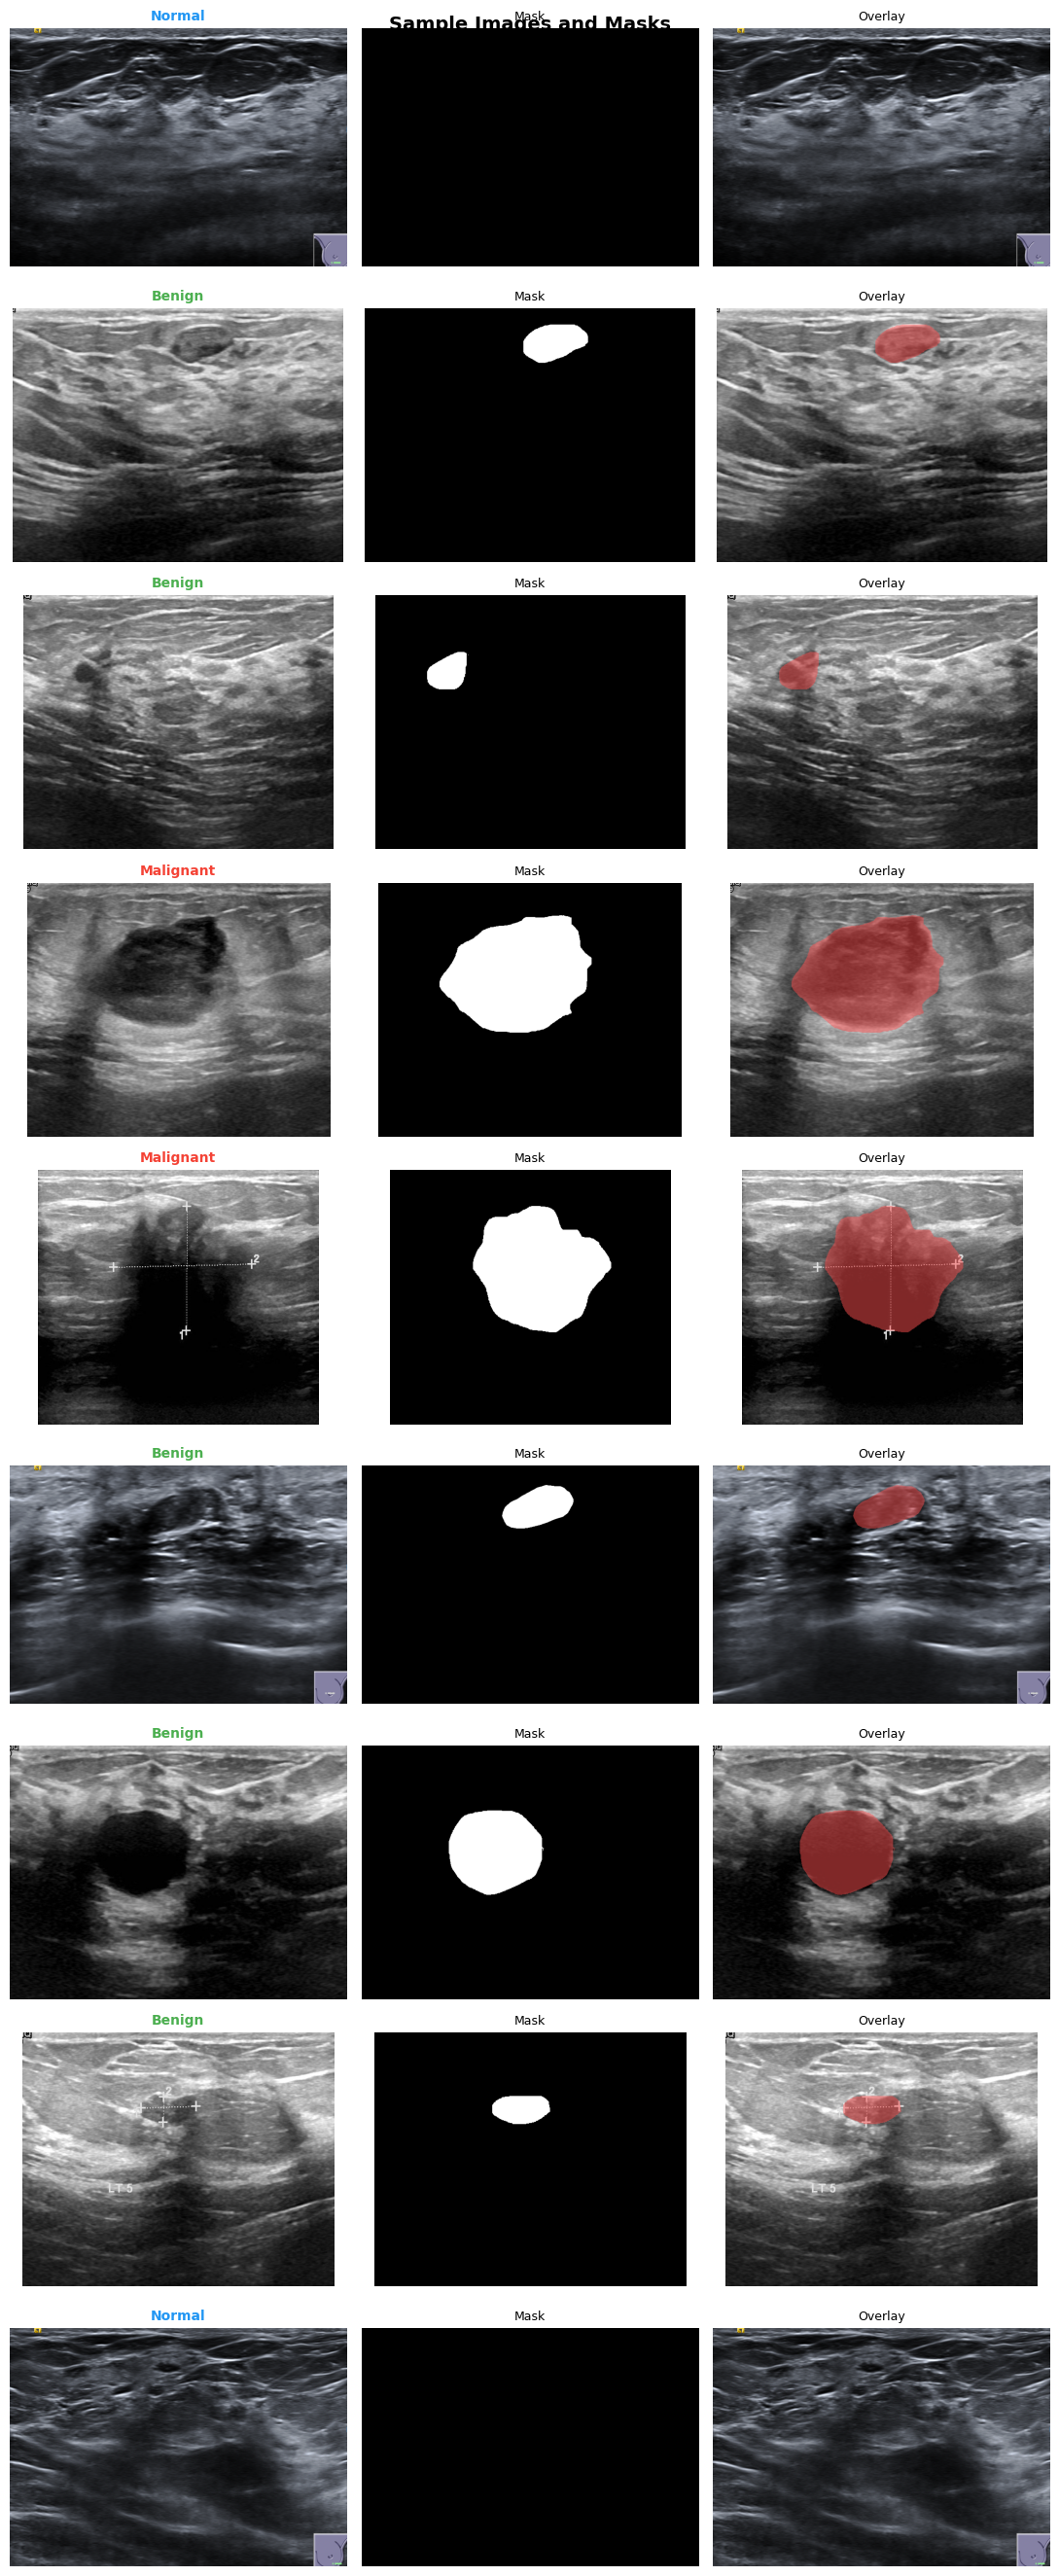

In [7]:
# ============================================================
# CELL 7 — Visualise Sample Images + Masks
# ============================================================

def visualise_samples(df: pd.DataFrame, n: int = 9,
                      title: str = "Sample Images & Masks"):
    fig, axes = plt.subplots(n, 3, figsize=(11, n * 3))
    indices   = random.sample(range(len(df)), min(n, len(df)))
    palette   = {0: "#4CAF50", 1: "#F44336", 2: "#2196F3"}
    cname     = {0: "Benign",  1: "Malignant", 2: "Normal"}

    for row_i, idx in enumerate(indices):
        rec   = df.iloc[idx]
        img   = np.array(Image.open(rec["image_path"]).convert("RGB"))
        label = int(rec["label"])

        axes[row_i, 0].imshow(img)
        axes[row_i, 0].set_title(
            f"{cname[label]}",
            color=palette[label], fontweight="bold", fontsize=10)
        axes[row_i, 0].axis("off")

        if rec["mask_path"] and os.path.exists(str(rec["mask_path"])):
            mask = np.array(Image.open(str(rec["mask_path"])).convert("L"))
            axes[row_i, 1].imshow(mask, cmap="gray")
        else:
            axes[row_i, 1].imshow(
                np.zeros((CFG.IMG_SIZE, CFG.IMG_SIZE)), cmap="gray")
        axes[row_i, 1].set_title("Mask", fontsize=9)
        axes[row_i, 1].axis("off")

        # Overlay: image + mask contour
        overlay = img.copy()
        if rec["mask_path"] and os.path.exists(str(rec["mask_path"])):
            m = np.array(Image.open(str(rec["mask_path"])).convert("L").resize(
                (img.shape[1], img.shape[0]), Image.NEAREST))
            m_bin = (m > 127).astype(np.uint8)
            overlay[m_bin == 1] = (
                overlay[m_bin == 1] * 0.5 +
                np.array([255, 80, 80]) * 0.5
            ).astype(np.uint8)
        axes[row_i, 2].imshow(overlay)
        axes[row_i, 2].set_title("Overlay", fontsize=9)
        axes[row_i, 2].axis("off")

    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/{title.replace(' ', '_')}.png",
                dpi=120, bbox_inches="tight")
    plt.show()


visualise_samples(df, n=9, title="Sample Images and Masks")


In [9]:
# ============================================================
# CELL 8 — Multi-Task Swin-T UNet Architecture
#
#  ┌──────────────────────────────────────────────────────┐
#  │  Input image  (B, 3, 224, 224)                       │
#  ├──────────────────────────────────────────────────────┤
#  │  Swin-T Encoder  (pretrained ImageNet)               │
#  │   → hierarchical feature maps at 4 scales            │
#  │   → bottleneck: (B, 768, 7, 7)                       │
#  ├───────────────┬──────────────────────────────────────┤
#  │ UNet Decoder  │  Classification Head                 │
#  │  skip-connect │   GAP → MLP → 3-class logits         │
#  │  → seg logits │                                      │
#  └───────────────┴──────────────────────────────────────┘
# ============================================================


class AttentionClassificationHead(nn.Module):
    """
    Attention-pooled classification head applied to the encoder bottleneck.
    Outperforms plain GAP on spatially-structured medical features.
    """
    def __init__(self, in_channels: int, num_classes: int, dropout: float = 0.4):
        super().__init__()

        # Channel-attention gate
        self.channel_att = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(in_channels, in_channels // 8),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // 8, in_channels),
            nn.Sigmoid(),
        )

        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.gmp  = nn.AdaptiveMaxPool2d(1)

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_channels * 2, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        # x: (B, C, H, W)
        att     = self.channel_att(x).unsqueeze(-1).unsqueeze(-1)
        x_att   = x * att
        avg_p   = self.gap(x_att)           # (B, C, 1, 1)
        max_p   = self.gmp(x_att)
        pooled  = torch.cat([avg_p, max_p], dim=1)  # (B, 2C, 1, 1)
        return self.head(pooled)


# ──────────────────────────────────────────────────────────────────────────────
class MultiTaskSwinUNet(nn.Module):
    """
    Single-forward-pass model that simultaneously outputs:
      • seg_logits  : (B, 1, H, W)   binary segmentation mask
      • cls_logits  : (B, 3)         3-class (benign/malignant/normal)
    """
    def __init__(self,
                 encoder_name   : str   = CFG.ENCODER,
                 encoder_weights: str   = CFG.ENC_WEIGHTS,
                 num_classes    : int   = CFG.NUM_CLASSES,
                 dropout        : float = CFG.DROPOUT):
        super().__init__()

        self.unet = smp.Unet(
            encoder_name         = encoder_name,
            encoder_weights      = encoder_weights,
            in_channels          = CFG.CHANNELS,
            classes              = 1,
            activation           = None,
            decoder_use_batchnorm= True,
            decoder_channels     = (256, 128, 64, 32, 16),
        )

        # Bottleneck channel count (Swin-T = 768)
        enc_out_ch = self.unet.encoder.out_channels[-1]
        print(f"  Encoder out_channels : {self.unet.encoder.out_channels}")
        print(f"  Bottleneck channels  : {enc_out_ch}")

        self.cls_head = AttentionClassificationHead(
            in_channels = enc_out_ch,
            num_classes = num_classes,
            dropout     = dropout,
        )

    def forward(self, x):
        features = self.unet.encoder(x)          # list of feature maps

        # ── Segmentation ─────────────────────────────────────
        try:
            dec_out    = self.unet.decoder(*features)
        except TypeError:
            dec_out    = self.unet.decoder(features)
        seg_logits = self.unet.segmentation_head(dec_out)   # (B,1,H,W)

        # ── Classification from bottleneck ───────────────────
        bottleneck = features[-1]               # (B, 768, 7, 7)
        cls_logits = self.cls_head(bottleneck)  # (B, 3)

        return seg_logits, cls_logits


# ── Sanity check ─────────────────────────────────────────────
print("\nBuilding Swin-T UNet …")
_model  = MultiTaskSwinUNet()
_dummy  = torch.randn(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE)
_s, _c  = _model(_dummy)
print(f"  Segmentation output : {_s.shape}")
print(f"  Classification output: {_c.shape}")

total_p     = sum(p.numel() for p in _model.parameters())
train_p     = sum(p.numel() for p in _model.parameters() if p.requires_grad)
print(f"  Total parameters   : {total_p:,}")
print(f"  Trainable params   : {train_p:,}")
print(f"  Model size (fp32)  : {total_p * 4 / 1024**2:.2f} MB")
del _model, _dummy, _s, _c


Building Swin-T UNet …


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

  Encoder out_channels : [3, 0, 96, 192, 384, 768]
  Bottleneck channels  : 768
  Segmentation output : torch.Size([2, 1, 224, 224])
  Classification output: torch.Size([2, 3])
  Total parameters   : 32,696,878
  Trainable params   : 32,696,878
  Model size (fp32)  : 124.73 MB


In [10]:
# ============================================================
# CELL 9 — Loss Functions
#
# Segmentation : BCE  +  Dice  +  Tversky (α=0.3, β=0.7)
#   • Tversky with high β penalises false-negatives harder
#     → better sensitivity for small lesions
# Classification: CrossEntropy with label smoothing
# ============================================================
class DiceLoss(nn.Module):
    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets):
        probs  = torch.sigmoid(logits)
        flat_p = probs.view(-1)
        flat_t = targets.view(-1)
        inter  = (flat_p * flat_t).sum()
        denom  = flat_p.sum() + flat_t.sum() + self.smooth
        return 1.0 - (2.0 * inter + self.smooth) / denom

class TverskyLoss(nn.Module):
    """Tversky index: higher β → penalise FN more (recall-oriented)."""
    def __init__(self, alpha: float = 0.30, beta: float = 0.70,
                 smooth: float = 1.0):
        super().__init__()
        self.alpha  = alpha
        self.beta   = beta
        self.smooth = smooth
    def forward(self, logits, targets):
        probs  = torch.sigmoid(logits)
        flat_p = probs.view(-1)
        flat_t = targets.view(-1)
        tp     = (flat_p * flat_t).sum()
        fp     = (flat_p * (1 - flat_t)).sum()
        fn     = ((1 - flat_p) * flat_t).sum()
        return 1.0 - (tp + self.smooth) / (
            tp + self.alpha * fp + self.beta * fn + self.smooth)

class FocalTverskyLoss(nn.Module):
    """Focal-Tversky: raise Tversky loss to power γ for hard examples."""
    def __init__(self, alpha=0.30, beta=0.70, gamma=0.75, smooth=1.0):
        super().__init__()
        self._tversky = TverskyLoss(alpha, beta, smooth)
        self.gamma    = gamma
    def forward(self, logits, targets):
        tv = self._tversky(logits, targets)
        return tv ** self.gamma

class SegmentationLoss(nn.Module):
    """Combined segmentation loss: 0.35 BCE + 0.35 Dice + 0.30 FocalTversky."""
    def __init__(self):
        super().__init__()
        self.bce          = nn.BCEWithLogitsLoss()
        self.dice         = DiceLoss()
        self.focal_tversky= FocalTverskyLoss(alpha=0.30, beta=0.70, gamma=0.75)
    def forward(self, logits, targets):
        return (0.35 * self.bce(logits, targets)
              + 0.35 * self.dice(logits, targets)
              + 0.30 * self.focal_tversky(logits, targets))

class MultiTaskLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.seg_loss = SegmentationLoss()
        # Label smoothing 0.10 prevents over-confidence
        self.cls_loss = nn.CrossEntropyLoss(label_smoothing=0.10)
    def forward(self, seg_logits, cls_logits, masks, labels):
        l_seg  = self.seg_loss(seg_logits, masks)
        l_cls  = self.cls_loss(cls_logits, labels)
        total  = CFG.SEG_WEIGHT * l_seg + CFG.CLS_WEIGHT * l_cls
        return total, l_seg, l_cls

print("✔ Loss functions defined.")

✔ Loss functions defined.


In [11]:
# ============================================================
# CELL 10 — Metric Helper Functions
# ============================================================
EPS = 1e-7
def compute_iou(pred, true, thr=0.5):
    pred_bin = (pred > thr).float()
    inter    = (pred_bin * true).sum()
    union    = (pred_bin + true).clamp(0, 1).sum()
    return ((inter + EPS) / (union + EPS)).item()

def compute_dice(pred, true, thr=0.5):
    pred_bin = (pred > thr).float()
    inter    = (pred_bin * true).sum()
    return ((2 * inter + EPS) /
            (pred_bin.sum() + true.sum() + EPS)).item()

def compute_pixel_acc(pred, true, thr=0.5):
    pred_bin = (pred > thr).float()
    return ((pred_bin == true).float().sum() / pred.numel()).item()

def compute_seg_precision(pred, true, thr=0.5):
    p  = (pred > thr).float()
    tp = (p * true).sum()
    fp = (p * (1 - true)).sum()
    return ((tp + EPS) / (tp + fp + EPS)).item()

def compute_seg_recall(pred, true, thr=0.5):
    p  = (pred > thr).float()
    tp = (p * true).sum()
    fn = ((1 - p) * true).sum()
    return ((tp + EPS) / (tp + fn + EPS)).item()

def batch_seg_metrics(seg_probs, masks):
    """Compute per-sample seg metrics and return mean over the batch."""
    bs   = seg_probs.size(0)
    ious = [compute_iou(seg_probs[i], masks[i])           for i in range(bs)]
    dice = [compute_dice(seg_probs[i], masks[i])          for i in range(bs)]
    pacc = [compute_pixel_acc(seg_probs[i], masks[i])     for i in range(bs)]
    prec = [compute_seg_precision(seg_probs[i], masks[i]) for i in range(bs)]
    rec  = [compute_seg_recall(seg_probs[i], masks[i])    for i in range(bs)]
    return ious, dice, pacc, prec, rec

print("✔ Metric helpers defined.")

✔ Metric helpers defined.


In [12]:
# ============================================================
# CELL 11 — Early Stopping
# ============================================================
class EarlyStopping:
    """
    Monitors combined score = 0.5 × val_dice + 0.5 × val_cls_acc.
    Saves the best checkpoint and signals stop after `patience` epochs
    without improvement.
    """
    def __init__(self, patience: int = CFG.EARLY_STOP_PAT,
                 min_delta: float = 5e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_score = None
        self.stop       = False

    def __call__(self, score: float) -> bool:
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best_score = score
            self.counter    = 0
        return self.stop

print("✔ EarlyStopping defined.")

✔ EarlyStopping defined.


In [13]:
# ============================================================
# CELL 12 — Training & Validation Loops
# ============================================================

def build_optimizer(model: nn.Module) -> optim.Optimizer:
    enc_ids    = {id(p) for p in model.unet.encoder.parameters()}
    enc_params = [p for p in model.parameters() if id(p) in enc_ids]
    oth_params = [p for p in model.parameters() if id(p) not in enc_ids]
    return optim.AdamW([
        {"params": enc_params, "lr": CFG.LR * CFG.ENCODER_LR_MULT,
         "weight_decay": CFG.WEIGHT_DECAY},
        {"params": oth_params, "lr": CFG.LR,
         "weight_decay": CFG.WEIGHT_DECAY},
    ])


def build_scheduler(optimizer, n_batches: int):
    """Warmup (linear) for WARMUP_EPOCHS, then CosineAnnealing."""
    warmup = LinearLR(
        optimizer,
        start_factor=0.1, end_factor=1.0,
        total_iters=CFG.WARMUP_EPOCHS)
    cosine = CosineAnnealingLR(
        optimizer,
        T_max=CFG.T_MAX - CFG.WARMUP_EPOCHS,
        eta_min=CFG.MIN_LR)
    return SequentialLR(
        optimizer,
        schedulers=[warmup, cosine],
        milestones=[CFG.WARMUP_EPOCHS])


# ──────────────────────────────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion,
                    scaler, device, accum_steps=1):
    model.train()
    total_loss = seg_l = cls_l = 0.0
    all_preds, all_labels = [], []
    all_iou, all_dice     = [], []

    optimizer.zero_grad()
    for step, (images, masks, labels) in enumerate(loader):
        images = images.to(device, non_blocking=True)
        masks  = masks .to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast(enabled=CFG.AMP):
            seg_logits, cls_logits = model(images)
            loss, l_seg, l_cls = criterion(seg_logits, cls_logits, masks, labels)
            loss = loss / accum_steps

        scaler.scale(loss).backward()

        if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += l_seg.item() * CFG.SEG_WEIGHT + l_cls.item() * CFG.CLS_WEIGHT
        seg_l      += l_seg.item()
        cls_l      += l_cls.item()

        all_preds .extend(cls_logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        with torch.no_grad():
            probs = torch.sigmoid(seg_logits).detach()
        ious, dice, *_ = batch_seg_metrics(probs, masks)
        all_iou .extend(ious)
        all_dice.extend(dice)

    n = len(loader)
    return {
        "loss"    : total_loss / n,
        "seg_loss": seg_l      / n,
        "cls_loss": cls_l      / n,
        "cls_acc" : accuracy_score(all_labels, all_preds),
        "iou"     : float(np.mean(all_iou)),
        "dice"    : float(np.mean(all_dice)),
    }


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = seg_l = cls_l = 0.0
    all_preds, all_labels = [], []
    all_iou, all_dice     = [], []

    for images, masks, labels in loader:
        images = images.to(device, non_blocking=True)
        masks  = masks .to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast(enabled=CFG.AMP):
            seg_logits, cls_logits = model(images)
            _, l_seg, l_cls = criterion(seg_logits, cls_logits, masks, labels)

        total_loss += l_seg.item() * CFG.SEG_WEIGHT + l_cls.item() * CFG.CLS_WEIGHT
        seg_l      += l_seg.item()
        cls_l      += l_cls.item()

        all_preds .extend(cls_logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        probs = torch.sigmoid(seg_logits)
        ious, dice, *_ = batch_seg_metrics(probs, masks)
        all_iou .extend(ious)
        all_dice.extend(dice)

    n = len(loader)
    return {
        "loss"    : total_loss / n,
        "seg_loss": seg_l      / n,
        "cls_loss": cls_l      / n,
        "cls_acc" : accuracy_score(all_labels, all_preds),
        "iou"     : float(np.mean(all_iou)),
        "dice"    : float(np.mean(all_dice)),
    }, all_labels, all_preds


print("✔ Training and validation loops defined.")

✔ Training and validation loops defined.


In [14]:
# ============================================================
# CELL 13 — Full Training Pipeline  (shared for Phase 1 & 2)
# ============================================================
def train_pipeline(phase: str, augment: bool):
    """
    phase   : 'Phase1_NoAug' | 'Phase2_WithAug'
    augment : False for Phase 1, True for Phase 2
    Returns : (history dict, test_loader, model_info dict)
    """
    print(f"\n{'='*62}")
    print(f"  TRAINING  ─  {phase}")
    print(f"  Augmentation : {'ENABLED  (strong)' if augment else 'DISABLED (baseline)'}")
    print(f"{'='*62}\n")
    seed_everything()
    train_loader, val_loader, test_loader = build_loaders(augment)
    model     = MultiTaskSwinUNet().to(CFG.DEVICE)
    criterion = MultiTaskLoss()
    optimizer = build_optimizer(model)
    scaler    = GradScaler(enabled=CFG.AMP)
    scheduler = build_scheduler(optimizer, len(train_loader))
    es        = EarlyStopping()
    history      = defaultdict(list)
    best_score   = 0.0
    best_dice    = 0.0
    best_acc     = 0.0
    ckpt_path    = os.path.join(CFG.SAVE_DIR, f"best_{phase}.pth")
    total_time   = 0.0
    actual_epochs = 0
    for epoch in range(1, CFG.EPOCHS + 1):
        t0 = time.time()
        train_m = train_one_epoch(
            model, train_loader, optimizer, criterion,
            scaler, CFG.DEVICE, accum_steps=CFG.ACCUM_STEPS)
        val_m, _, _ = validate(model, val_loader, criterion, CFG.DEVICE)
        scheduler.step()
        epoch_time  = time.time() - t0
        total_time += epoch_time
        actual_epochs += 1
        for k, v in train_m.items():
            history[f"train_{k}"].append(v)
        for k, v in val_m.items():
            history[f"val_{k}"].append(v)
        history["epoch_time"].append(epoch_time)
        history["lr"].append(optimizer.param_groups[1]["lr"])
        combined = 0.5 * val_m["dice"] + 0.5 * val_m["cls_acc"]
        if combined > best_score:
            best_score = combined
            best_dice  = val_m["dice"]
            best_acc   = val_m["cls_acc"]
            torch.save({
                "epoch"      : epoch,
                "state_dict" : model.state_dict(),
                "best_score" : best_score,
            }, ckpt_path)
        lr_now = optimizer.param_groups[1]["lr"]
        print(
            f"  Ep {epoch:3d}/{CFG.EPOCHS} | "
            f"Time: {epoch_time:.1f}s | "
            f"Train Loss: {train_m['loss']:.4f} | "
            f"Train Acc: {train_m['cls_acc']:.4f} | "
            f"Val Loss: {val_m['loss']:.4f} | "
            f"Val Acc: {val_m['cls_acc']:.4f} | "
            f"Val Dice: {val_m['dice']:.4f} | "
            f"Val IoU: {val_m['iou']:.4f} | "
            f"LR: {lr_now:.2e}")
        if es(combined):
            print(f"  ↳ Early stopping at epoch {epoch}")
            break
    # ── Reload best weights ──────────────────────────────────
    ckpt = torch.load(ckpt_path, map_location=CFG.DEVICE)
    model.load_state_dict(ckpt["state_dict"])
    print(f"\n  ✔ Best checkpoint restored (epoch {ckpt['epoch']})")
    total_p = sum(p.numel() for p in model.parameters())
    model_info = {
        "phase"          : phase,
        "augment"        : augment,
        "total_params"   : total_p,
        "model_size_mb"  : total_p * 4 / 1024**2,
        "total_train_time": total_time,
        "actual_epochs"  : actual_epochs,
        "avg_epoch_time" : total_time / actual_epochs,
        "best_val_dice"  : best_dice,
        "best_val_acc"   : best_acc,
    }
    print(f"  Total training time : {total_time/60:.1f} min")
    print(f"  Avg time / epoch    : {total_time/actual_epochs:.1f} s")
    print(f"  Best Val Dice       : {best_dice:.4f}")
    print(f"  Best Val Acc        : {best_acc:.4f}")
    return dict(history), test_loader, model, model_info

print("✔ train_pipeline defined.")

✔ train_pipeline defined.


In [15]:
# ============================================================
# CELL 14 — Evaluation Helpers
#   evaluate_classification()  ─ full cls metrics + conf matrix
#   evaluate_segmentation()    ─ full seg metrics
#   plot_training_curves()     ─ loss + accuracy/dice vs epochs
#   plot_confusion_matrix()
#   plot_qualitative_results() ─ image | mask | prediction overlays
# ============================================================

# ── Classification evaluation ────────────────────────────────
@torch.no_grad()
def evaluate_classification(model, loader, phase_label: str):
    model.eval()
    all_preds, all_labels, all_probs_list = [], [], []

    for images, masks, labels in loader:
        images = images.to(CFG.DEVICE, non_blocking=True)
        _, cls_logits = model(images)
        probs  = torch.softmax(cls_logits, dim=1).cpu().numpy()
        preds  = cls_logits.argmax(1).cpu().numpy()
        all_preds .extend(preds)
        all_labels.extend(labels.numpy())
        all_probs_list.extend(probs)

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec  = recall_score   (y_true, y_pred, average="macro", zero_division=0)
    f1   = f1_score       (y_true, y_pred, average="macro", zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)

    print(f"\n  ── Classification Metrics  [{phase_label}] ──")
    print(f"     Accuracy   : {acc:.4f}  ({acc*100:.2f} %)")
    print(f"     Precision  : {prec:.4f}")
    print(f"     Recall     : {rec:.4f}")
    print(f"     F1 (macro) : {f1:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=CFG.CLASSES)}")

    return {"accuracy": acc, "precision": prec,
            "recall": rec, "f1": f1, "cm": cm,
            "y_true": y_true, "y_pred": y_pred}


# ── Segmentation evaluation ──────────────────────────────────
@torch.no_grad()
def evaluate_segmentation(model, loader, phase_label: str):
    model.eval()
    all_iou, all_dice, all_pacc, all_prec, all_rec = [], [], [], [], []

    for images, masks, labels in loader:
        images = images.to(CFG.DEVICE, non_blocking=True)
        masks  = masks .to(CFG.DEVICE, non_blocking=True)
        seg_logits, _ = model(images)
        probs = torch.sigmoid(seg_logits)
        ious, dice, pacc, prec, rec = batch_seg_metrics(probs, masks)
        all_iou .extend(ious)
        all_dice.extend(dice)
        all_pacc.extend(pacc)
        all_prec.extend(prec)
        all_rec .extend(rec)

    metrics = {
        "iou"        : float(np.mean(all_iou)),
        "dice"       : float(np.mean(all_dice)),
        "pixel_acc"  : float(np.mean(all_pacc)),
        "precision"  : float(np.mean(all_prec)),
        "recall"     : float(np.mean(all_rec)),
    }
    print(f"\n  ── Segmentation Metrics  [{phase_label}] ──")
    for k, v in metrics.items():
        print(f"     {k:<12}: {v:.4f}  ({v*100:.2f} %)")
    return metrics


# ── Training curves ──────────────────────────────────────────
def plot_training_curves(history: dict, phase: str):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    def _plot(ax, train_key, val_key, ylabel, title):
        ax.plot(epochs, history[train_key], label="Train", linewidth=2,
                color="#2196F3", marker="o", markersize=3)
        ax.plot(epochs, history[val_key],   label="Val",   linewidth=2,
                color="#F44336", marker="o", markersize=3)
        ax.set_xlabel("Epochs"); ax.set_ylabel(ylabel)
        ax.set_title(title, fontweight="bold")
        ax.legend(); ax.grid(alpha=0.3)

    # Top-left: Total Loss
    _plot(axes[0,0], "train_loss",    "val_loss",    "Loss",     "Total Loss")
    # Top-right: Classification Accuracy
    _plot(axes[0,1], "train_cls_acc", "val_cls_acc", "Accuracy", "Classification Accuracy")
    # Bottom-left: Segmentation Loss (BCE+Dice+Focal)
    _plot(axes[1,0], "train_seg_loss","val_seg_loss","Loss",     "Segmentation Loss (BCE+Dice+Focal)")
    # Bottom-right: IoU & Dice Score (4 lines)
    ax = axes[1,1]
    ax.plot(epochs, history["train_iou"],  label="Train IoU",  linewidth=2,
            color="#2196F3", linestyle="--", marker="o", markersize=3)
    ax.plot(epochs, history["val_iou"],    label="Val IoU",    linewidth=2,
            color="#F44336", linestyle="--", marker="o", markersize=3)
    ax.plot(epochs, history["train_dice"], label="Train Dice", linewidth=2,
            color="#2196F3", linestyle="-",  marker="o", markersize=3)
    ax.plot(epochs, history["val_dice"],   label="Val Dice",   linewidth=2,
            color="#F44336", linestyle="-",  marker="o", markersize=3)
    ax.set_xlabel("Epochs"); ax.set_ylabel("Score")
    ax.set_title("IoU & Dice Score", fontweight="bold")
    ax.legend(); ax.grid(alpha=0.3)

    fig.suptitle(f"Training Curves — {phase}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    save_path = f"/kaggle/working/training_curves_{phase}.png"
    plt.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {save_path}")


# ── Confusion matrix ─────────────────────────────────────────
def plot_confusion_matrix(cm: np.ndarray, phase: str):
    fig, ax = plt.subplots(figsize=(7, 6))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=False, fmt="", cmap="Blues",
                xticklabels=CFG.CLASSES, yticklabels=CFG.CLASSES,
                ax=ax, linewidths=0.5, linecolor="gray")

    for i in range(len(CFG.CLASSES)):
        for j in range(len(CFG.CLASSES)):
            ax.text(j + 0.5, i + 0.5,
                    f"{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)",
                    ha="center", va="center",
                    fontsize=11, fontweight="bold",
                    color="white" if cm_norm[i,j] > 0.5 else "black")

    ax.set_title(f"Confusion Matrix — {phase}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True",      fontsize=11)
    plt.tight_layout()
    save_path = f"/kaggle/working/confusion_matrix_{phase}.png"
    plt.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {save_path}")


# ── Qualitative segmentation results ─────────────────────────
@torch.no_grad()
def plot_qualitative_results(model, loader, phase: str, n_rows: int = 6):
    model.eval()
    CNAME = {0: "Benign", 1: "Malignant", 2: "Normal"}
    PAL   = {0: "#4CAF50", 1: "#F44336", 2: "#2196F3"}

    images_np, masks_np, labels_np, preds_np, seg_probs_np = [], [], [], [], []
    for imgs, msks, lbls in loader:
        imgs_dev = imgs.to(CFG.DEVICE)
        seg_l, cls_l = model(imgs_dev)
        seg_pr = torch.sigmoid(seg_l).cpu().numpy()
        cls_pr = cls_l.argmax(1).cpu().numpy()
        images_np.extend(imgs.numpy())
        masks_np .extend(msks.numpy())
        labels_np.extend(lbls.numpy())
        preds_np .extend(cls_pr)
        seg_probs_np.extend(seg_pr)
        if len(images_np) >= n_rows:
            break

    fig, axes = plt.subplots(n_rows, 4, figsize=(14, n_rows * 3.2))
    COL_TITLES = ["Image", "Ground Truth Mask", "Predicted Mask", "Overlay"]

    for col, t in enumerate(COL_TITLES):
        axes[0, col].set_title(t, fontsize=11, fontweight="bold", pad=4)

    _mean = np.array(_MEAN)[:, None, None]
    _std  = np.array(_STD )[:, None, None]

    for row in range(n_rows):
        img_t  = images_np[row]          # (3, H, W)
        img_np = np.clip((img_t * _std + _mean).transpose(1, 2, 0), 0, 1)
        gt_mask= masks_np[row][0]        # (H, W)
        pr_mask= (seg_probs_np[row][0] > 0.5).astype(np.uint8)
        dice_r = compute_dice(
            torch.tensor(seg_probs_np[row]),
            torch.tensor(masks_np[row]))
        true_l = labels_np[row]
        pred_l = preds_np[row]

        axes[row, 0].imshow(img_np)
        axes[row, 0].set_ylabel(
            f"GT: {CNAME[true_l]}\nPred: {CNAME[pred_l]}",
            color=PAL[pred_l], fontsize=8, rotation=0, labelpad=60)

        axes[row, 1].imshow(gt_mask, cmap="gray", vmin=0, vmax=1)
        axes[row, 2].imshow(pr_mask, cmap="gray", vmin=0, vmax=1)
        axes[row, 2].set_xlabel(f"Dice={dice_r:.3f}", fontsize=8)

        overlay = img_np.copy()
        overlay[pr_mask == 1] = (
            overlay[pr_mask == 1] * 0.5 + np.array([1.0, 0.2, 0.2]) * 0.5)
        axes[row, 3].imshow(np.clip(overlay, 0, 1))

        for col in range(4):
            axes[row, col].axis("off")

    fig.suptitle(f"Qualitative Segmentation Results — {phase}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    save_path = f"/kaggle/working/qualitative_{phase}.png"
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {save_path}")


print("✔ Evaluation and plotting helpers defined.")


✔ Evaluation and plotting helpers defined.


In [16]:
# ============================================================
# CELL 15 — PHASE 1: Train WITHOUT Augmentation
#   Objective: establish baseline performance
# ============================================================

history_p1, test_loader_p1, model_p1, info_p1 = train_pipeline(
    phase="Phase1_NoAug", augment=False)



  TRAINING  ─  Phase1_NoAug
  Augmentation : DISABLED (baseline)

  Encoder out_channels : [3, 0, 96, 192, 384, 768]
  Bottleneck channels  : 768
  Ep   1/80 | Time: 24.8s | Train Loss: 0.9143 | Train Acc: 0.4483 | Val Loss: 0.8522 | Val Acc: 0.6409 | Val Dice: 0.1362 | Val IoU: 0.0870 | LR: 5.60e-05
  Ep   2/80 | Time: 16.1s | Train Loss: 0.7869 | Train Acc: 0.6160 | Val Loss: 0.7391 | Val Acc: 0.7318 | Val Dice: 0.2669 | Val IoU: 0.1979 | LR: 9.20e-05
  Ep   3/80 | Time: 15.5s | Train Loss: 0.7108 | Train Acc: 0.6540 | Val Loss: 0.6484 | Val Acc: 0.7682 | Val Dice: 0.3670 | Val IoU: 0.3012 | LR: 1.28e-04
  Ep   4/80 | Time: 15.3s | Train Loss: 0.6075 | Train Acc: 0.7485 | Val Loss: 0.6674 | Val Acc: 0.6818 | Val Dice: 0.6161 | Val IoU: 0.5531 | LR: 1.64e-04
  Ep   5/80 | Time: 15.3s | Train Loss: 0.5277 | Train Acc: 0.7875 | Val Loss: 0.6114 | Val Acc: 0.7409 | Val Dice: 0.6254 | Val IoU: 0.5604 | LR: 2.00e-04
  Ep   6/80 | Time: 15.3s | Train Loss: 0.4601 | Train Acc: 0.8177 | Val 

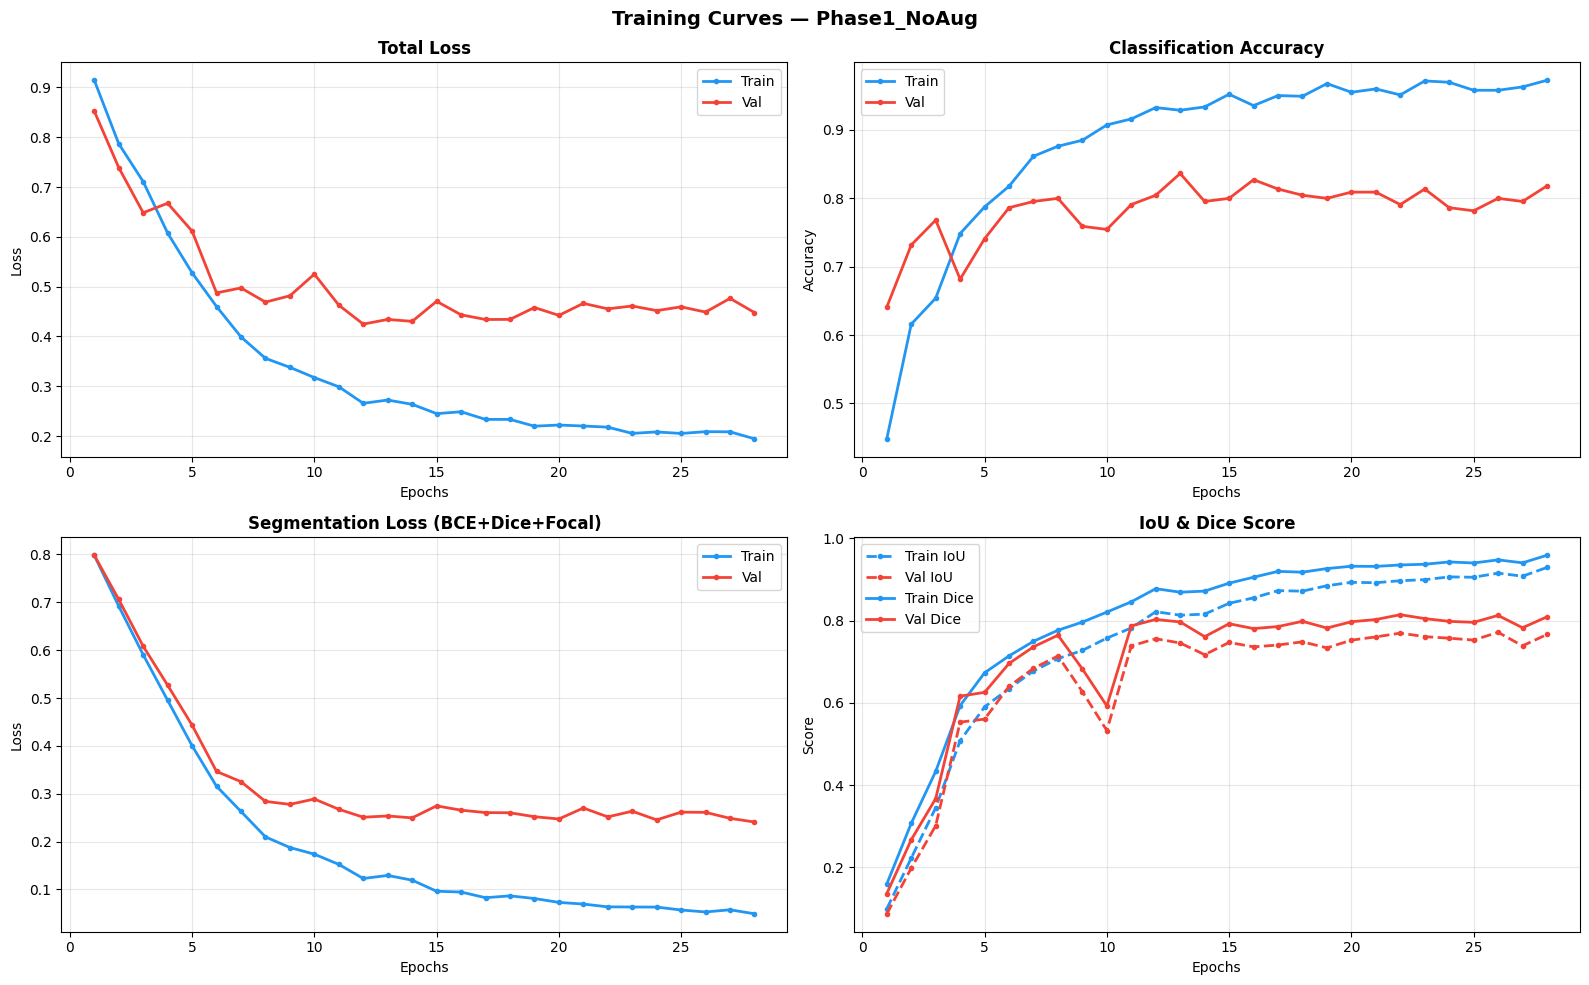

  Saved: /kaggle/working/training_curves_Phase1_NoAug.png


In [17]:
# ============================================================
# CELL 16 — Phase 1: Training Curves (Loss + Accuracy + Dice)
# ============================================================

plot_training_curves(history_p1, phase="Phase1_NoAug")



  ── Classification Metrics  [Phase 1 — No Augmentation] ──
     Accuracy   : 0.8326  (83.26 %)
     Precision  : 0.8370
     Recall     : 0.8048
     F1 (macro) : 0.8181

              precision    recall  f1-score   support

      benign       0.78      0.81      0.79        72
   malignant       0.88      0.72      0.79        39
      normal       0.85      0.89      0.87       110

    accuracy                           0.83       221
   macro avg       0.84      0.80      0.82       221
weighted avg       0.83      0.83      0.83       221


  Model Info:
    Total parameters : 32,696,878
    Model size       : 124.73 MB
    Epochs trained   : 28
    Total train time : 7.33 min
    Avg time / epoch : 15.70 s


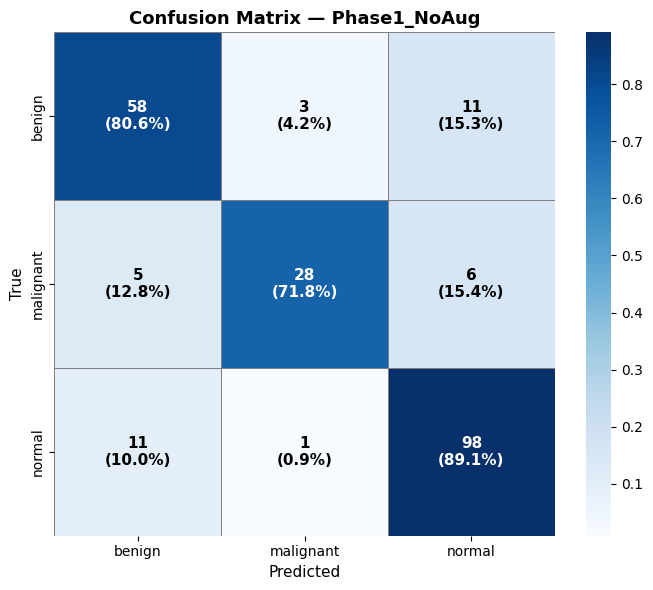

  Saved: /kaggle/working/confusion_matrix_Phase1_NoAug.png


In [18]:
# ============================================================
# CELL 17 — Phase 1: Classification Evaluation on Test Set
#   Metrics: Accuracy, Precision, Recall, F1, Confusion Matrix
#   Model stats: #parameters, model size, training time
# ============================================================

cls_results_p1 = evaluate_classification(
    model_p1, test_loader_p1, phase_label="Phase 1 — No Augmentation")

print(f"\n  Model Info:")
print(f"    Total parameters : {info_p1['total_params']:,}")
print(f"    Model size       : {info_p1['model_size_mb']:.2f} MB")
print(f"    Epochs trained   : {info_p1['actual_epochs']}")
print(f"    Total train time : {info_p1['total_train_time']/60:.2f} min")
print(f"    Avg time / epoch : {info_p1['avg_epoch_time']:.2f} s")

# Confusion matrix
plot_confusion_matrix(cls_results_p1["cm"], phase="Phase1_NoAug")


In [19]:
# ============================================================
# CELL 18 — Phase 1: Segmentation Evaluation on Test Set
#   Primary  : IoU (Jaccard), Dice (DSC)
#   Secondary: Pixel Accuracy, Precision, Recall
# ============================================================

seg_results_p1 = evaluate_segmentation(
    model_p1, test_loader_p1, phase_label="Phase 1 — No Augmentation")



  ── Segmentation Metrics  [Phase 1 — No Augmentation] ──
     iou         : 0.7572  (75.72 %)
     dice        : 0.8112  (81.12 %)
     pixel_acc   : 0.9779  (97.79 %)
     precision   : 0.8798  (87.98 %)
     recall      : 0.8316  (83.16 %)


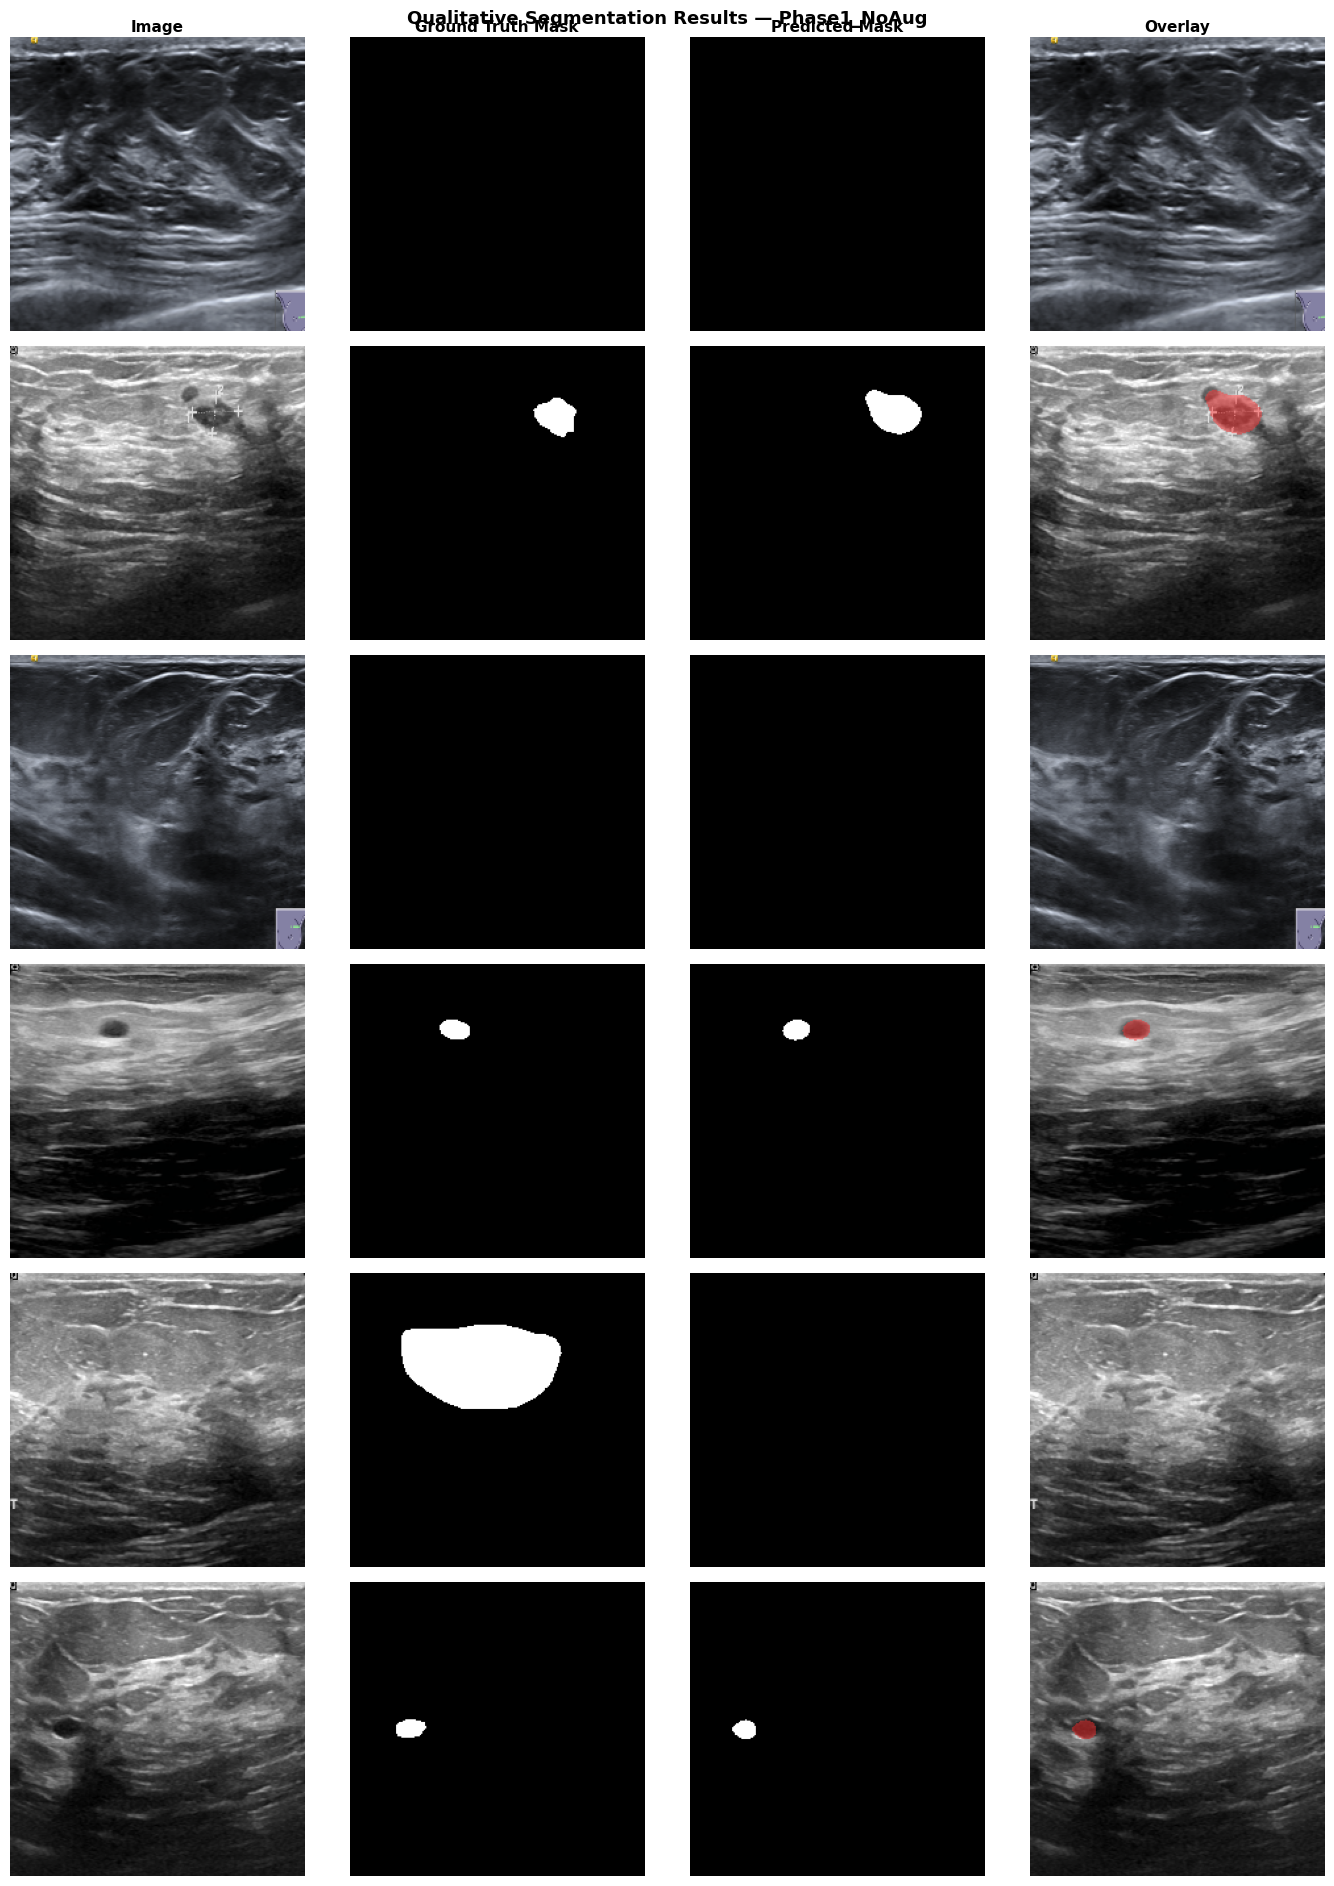

  Saved: /kaggle/working/qualitative_Phase1_NoAug.png


In [20]:
# ============================================================
# CELL 19 — Phase 1: Qualitative Segmentation Results
# ============================================================

plot_qualitative_results(model_p1, test_loader_p1,
                         phase="Phase1_NoAug", n_rows=6)


In [21]:
# ============================================================
# CELL 20 — PHASE 2: Train WITH Strong Augmentation
#   Objective: improve generalisation with 20 augmentation ops
#   Expected : +3–6 % accuracy, stable or improved Dice
# ============================================================

history_p2, test_loader_p2, model_p2, info_p2 = train_pipeline(
    phase="Phase2_WithAug", augment=True)



  TRAINING  ─  Phase2_WithAug
  Augmentation : ENABLED  (strong)

  Encoder out_channels : [3, 0, 96, 192, 384, 768]
  Bottleneck channels  : 768
  Ep   1/80 | Time: 19.2s | Train Loss: 0.9632 | Train Acc: 0.3431 | Val Loss: 0.9157 | Val Acc: 0.5591 | Val Dice: 0.1143 | Val IoU: 0.0708 | LR: 5.60e-05
  Ep   2/80 | Time: 18.6s | Train Loss: 0.8974 | Train Acc: 0.4035 | Val Loss: 0.8006 | Val Acc: 0.6182 | Val Dice: 0.2116 | Val IoU: 0.1498 | LR: 9.20e-05
  Ep   3/80 | Time: 18.1s | Train Loss: 0.8501 | Train Acc: 0.4425 | Val Loss: 0.7286 | Val Acc: 0.7000 | Val Dice: 0.2756 | Val IoU: 0.2111 | LR: 1.28e-04
  Ep   4/80 | Time: 18.2s | Train Loss: 0.7954 | Train Acc: 0.4951 | Val Loss: 0.6555 | Val Acc: 0.7545 | Val Dice: 0.5739 | Val IoU: 0.5144 | LR: 1.64e-04
  Ep   5/80 | Time: 18.4s | Train Loss: 0.7391 | Train Acc: 0.5419 | Val Loss: 0.6094 | Val Acc: 0.7409 | Val Dice: 0.6483 | Val IoU: 0.5863 | LR: 2.00e-04
  Ep   6/80 | Time: 18.2s | Train Loss: 0.6959 | Train Acc: 0.5653 | Val 

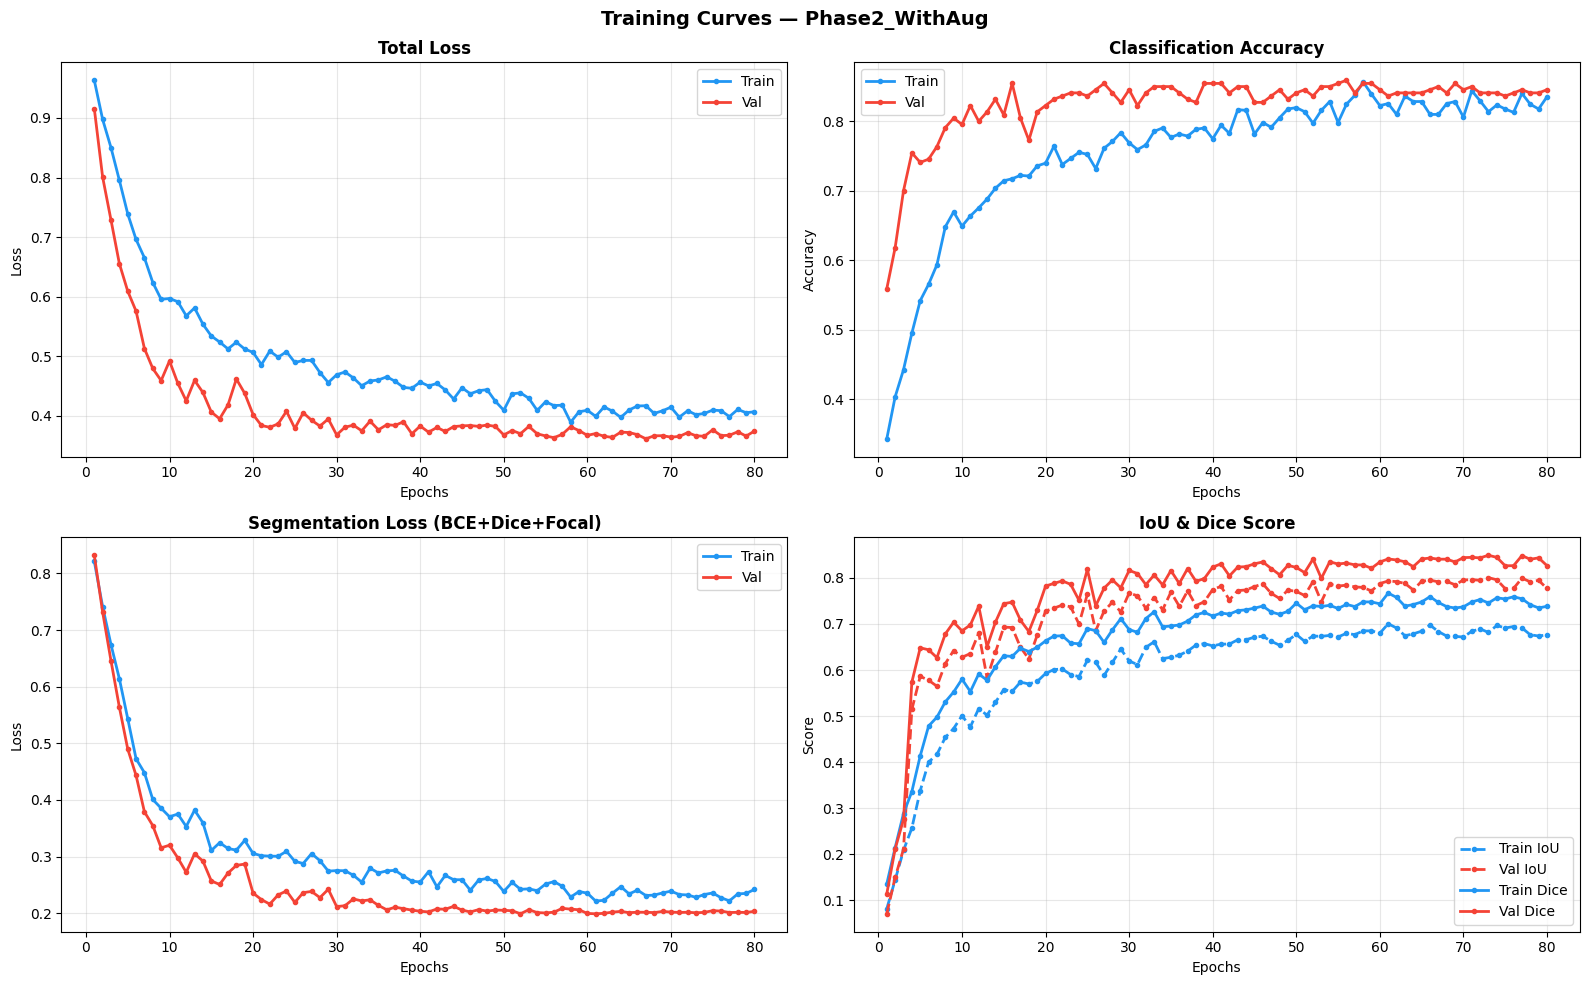

  Saved: /kaggle/working/training_curves_Phase2_WithAug.png


In [22]:
# ============================================================
# CELL 21 — Phase 2: Training Curves
# ============================================================

plot_training_curves(history_p2, phase="Phase2_WithAug")



  ── Classification Metrics  [Phase 2 — With Augmentation] ──
     Accuracy   : 0.8688  (86.88 %)
     Precision  : 0.8520
     Recall     : 0.8488
     F1 (macro) : 0.8503

              precision    recall  f1-score   support

      benign       0.82      0.83      0.83        72
   malignant       0.82      0.79      0.81        39
      normal       0.92      0.92      0.92       110

    accuracy                           0.87       221
   macro avg       0.85      0.85      0.85       221
weighted avg       0.87      0.87      0.87       221


  Model Info:
    Total parameters : 32,696,878
    Model size       : 124.73 MB
    Epochs trained   : 80
    Total train time : 24.35 min
    Avg time / epoch : 18.26 s


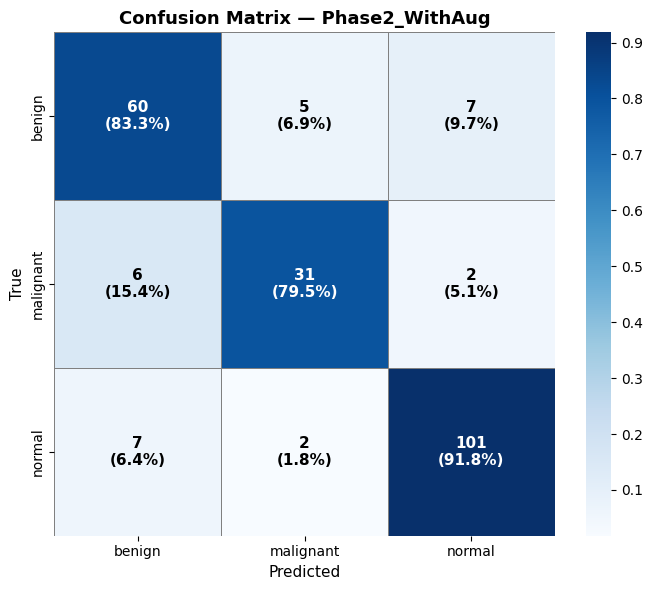

  Saved: /kaggle/working/confusion_matrix_Phase2_WithAug.png


In [23]:
# ============================================================
# CELL 22 — Phase 2: Classification Evaluation
# ============================================================

cls_results_p2 = evaluate_classification(
    model_p2, test_loader_p2, phase_label="Phase 2 — With Augmentation")

print(f"\n  Model Info:")
print(f"    Total parameters : {info_p2['total_params']:,}")
print(f"    Model size       : {info_p2['model_size_mb']:.2f} MB")
print(f"    Epochs trained   : {info_p2['actual_epochs']}")
print(f"    Total train time : {info_p2['total_train_time']/60:.2f} min")
print(f"    Avg time / epoch : {info_p2['avg_epoch_time']:.2f} s")

plot_confusion_matrix(cls_results_p2["cm"], phase="Phase2_WithAug")


In [24]:
# ============================================================
# CELL 23 — Phase 2: Segmentation Evaluation
# ============================================================

seg_results_p2 = evaluate_segmentation(
    model_p2, test_loader_p2, phase_label="Phase 2 — With Augmentation")



  ── Segmentation Metrics  [Phase 2 — With Augmentation] ──
     iou         : 0.7950  (79.50 %)
     dice        : 0.8482  (84.82 %)
     pixel_acc   : 0.9772  (97.72 %)
     precision   : 0.8841  (88.41 %)
     recall      : 0.8918  (89.18 %)


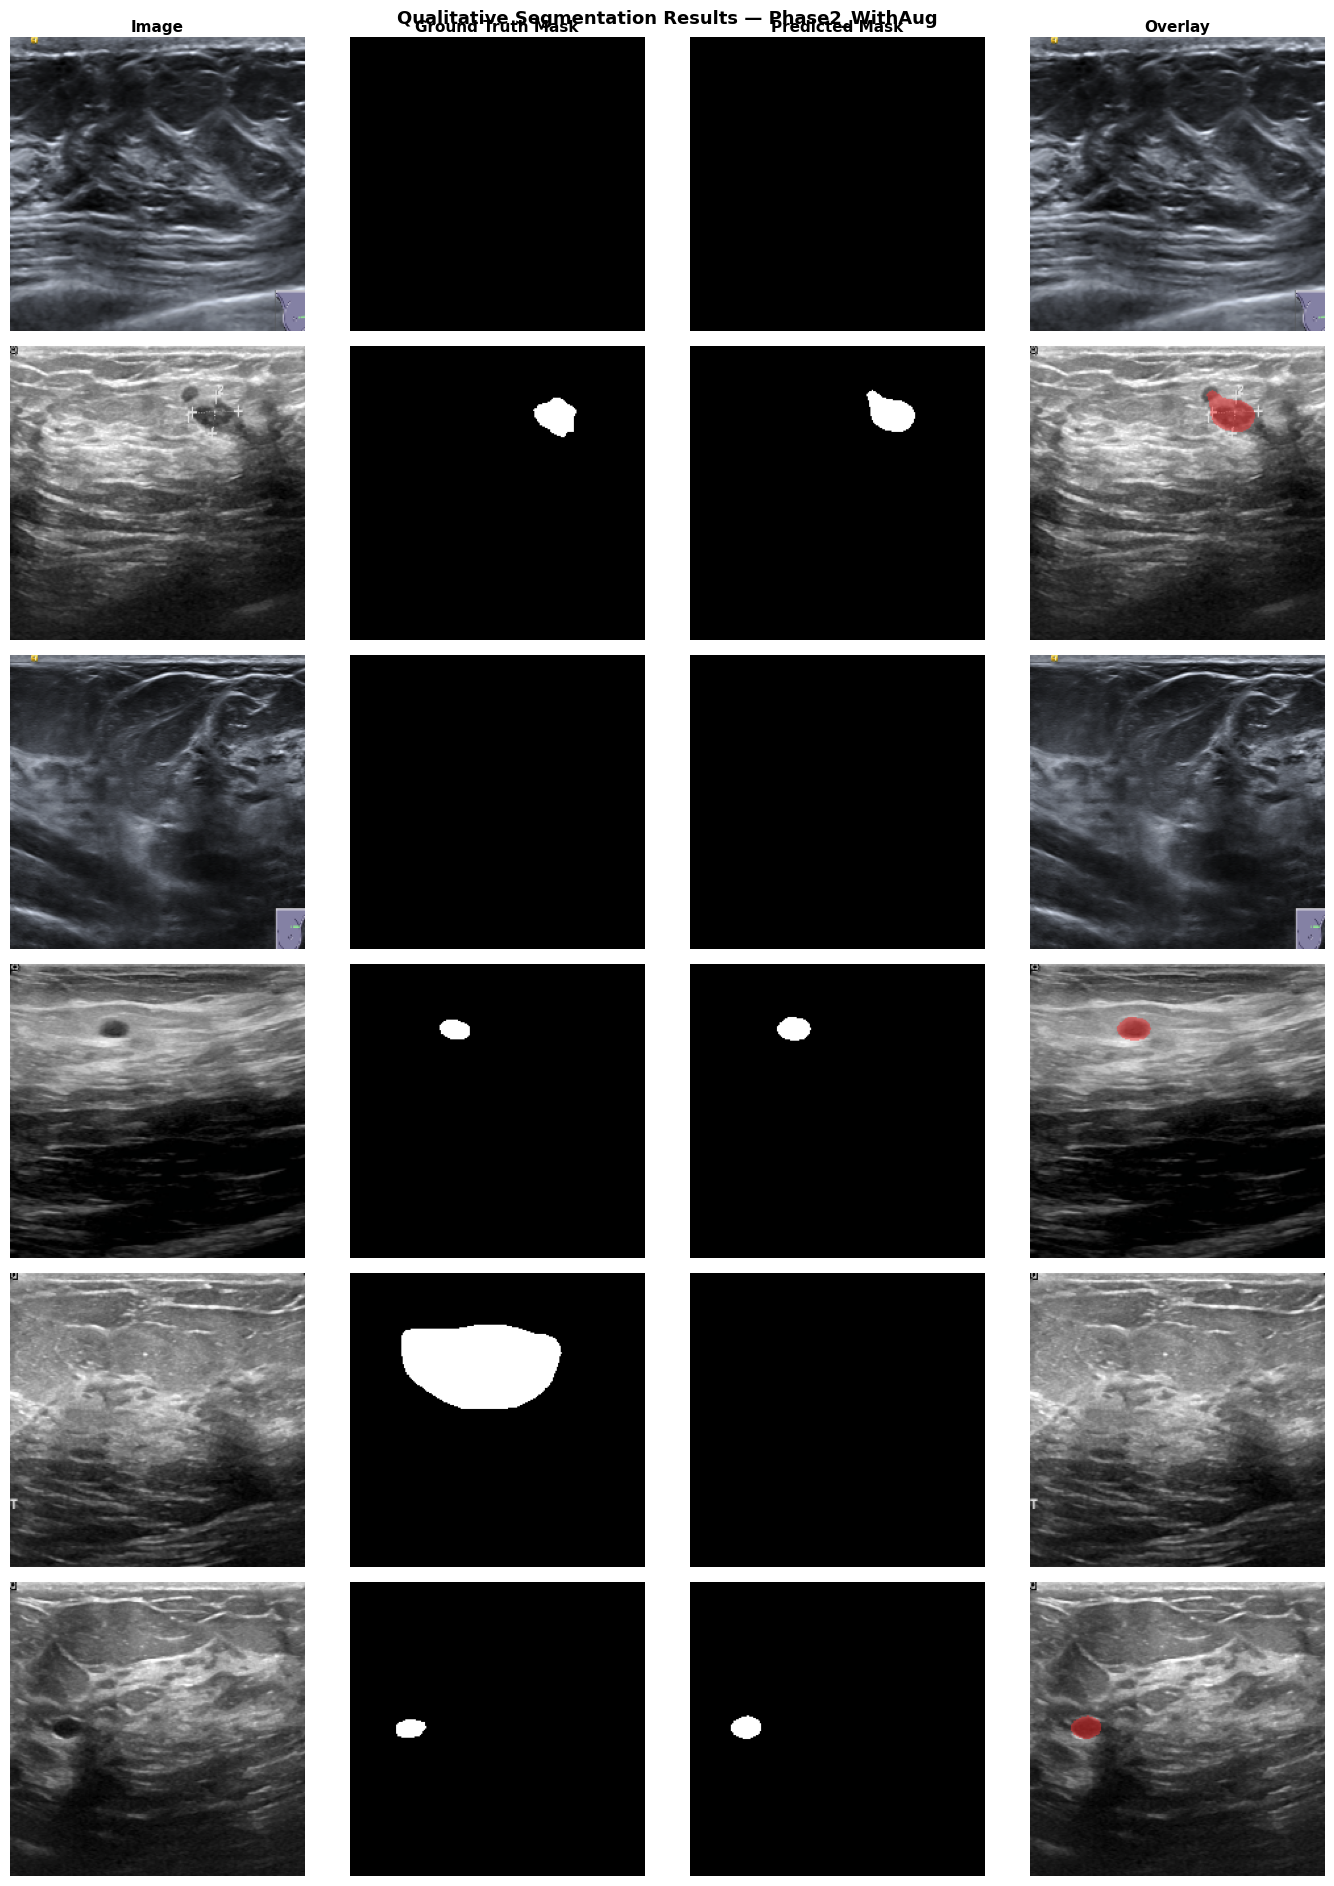

  Saved: /kaggle/working/qualitative_Phase2_WithAug.png


In [25]:
# ============================================================
# CELL 24 — Phase 2: Qualitative Segmentation Results
# ============================================================

plot_qualitative_results(model_p2, test_loader_p2,
                         phase="Phase2_WithAug", n_rows=6)



  FULL COMPARISON TABLE
                Metric Phase 1 — No Aug Phase 2 — With Aug
          Cls Accuracy           0.8326             0.8688
         Cls Precision           0.8370             0.8520
            Cls Recall           0.8048             0.8488
        Cls F1 (macro)           0.8181             0.8503
     Seg IoU (Jaccard)           0.7572             0.7950
        Seg Dice (DSC)           0.8112             0.8482
    Seg Pixel Accuracy           0.9779             0.9772
         Seg Precision           0.8798             0.8841
            Seg Recall           0.8316             0.8918
      Total Parameters       32,696,878         32,696,878
       Model Size (MB)           124.73             124.73
Total Train Time (min)             7.33              24.35
    Avg Epoch Time (s)            15.70              18.26

  Saved: /kaggle/working/comparison_table.csv


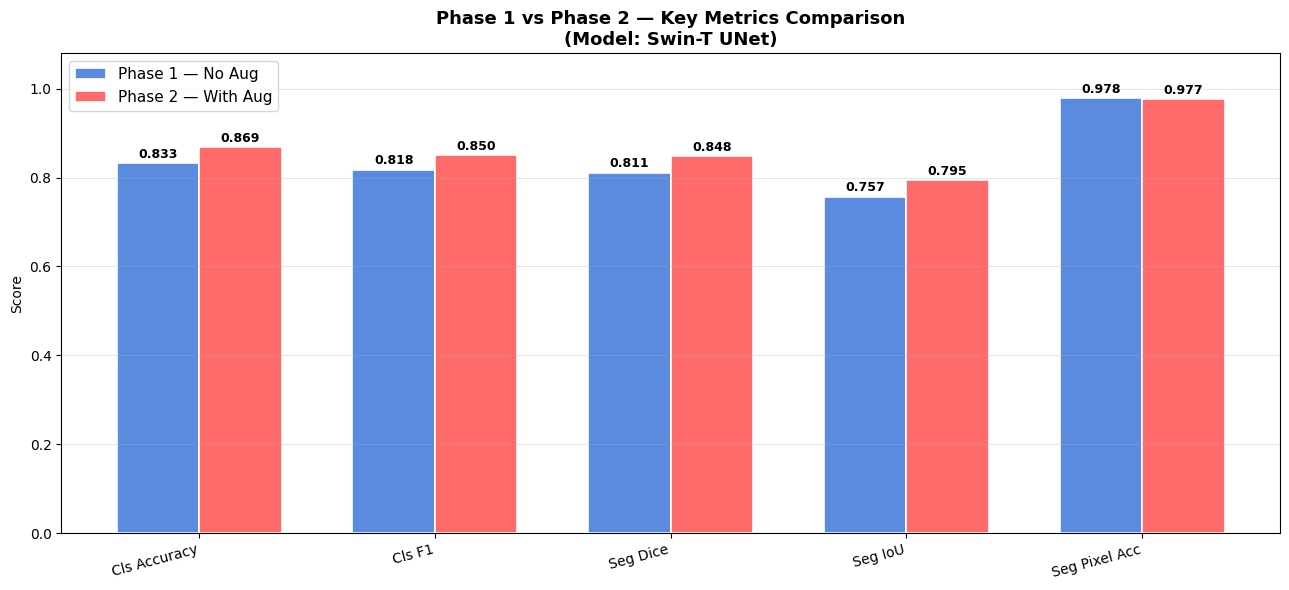

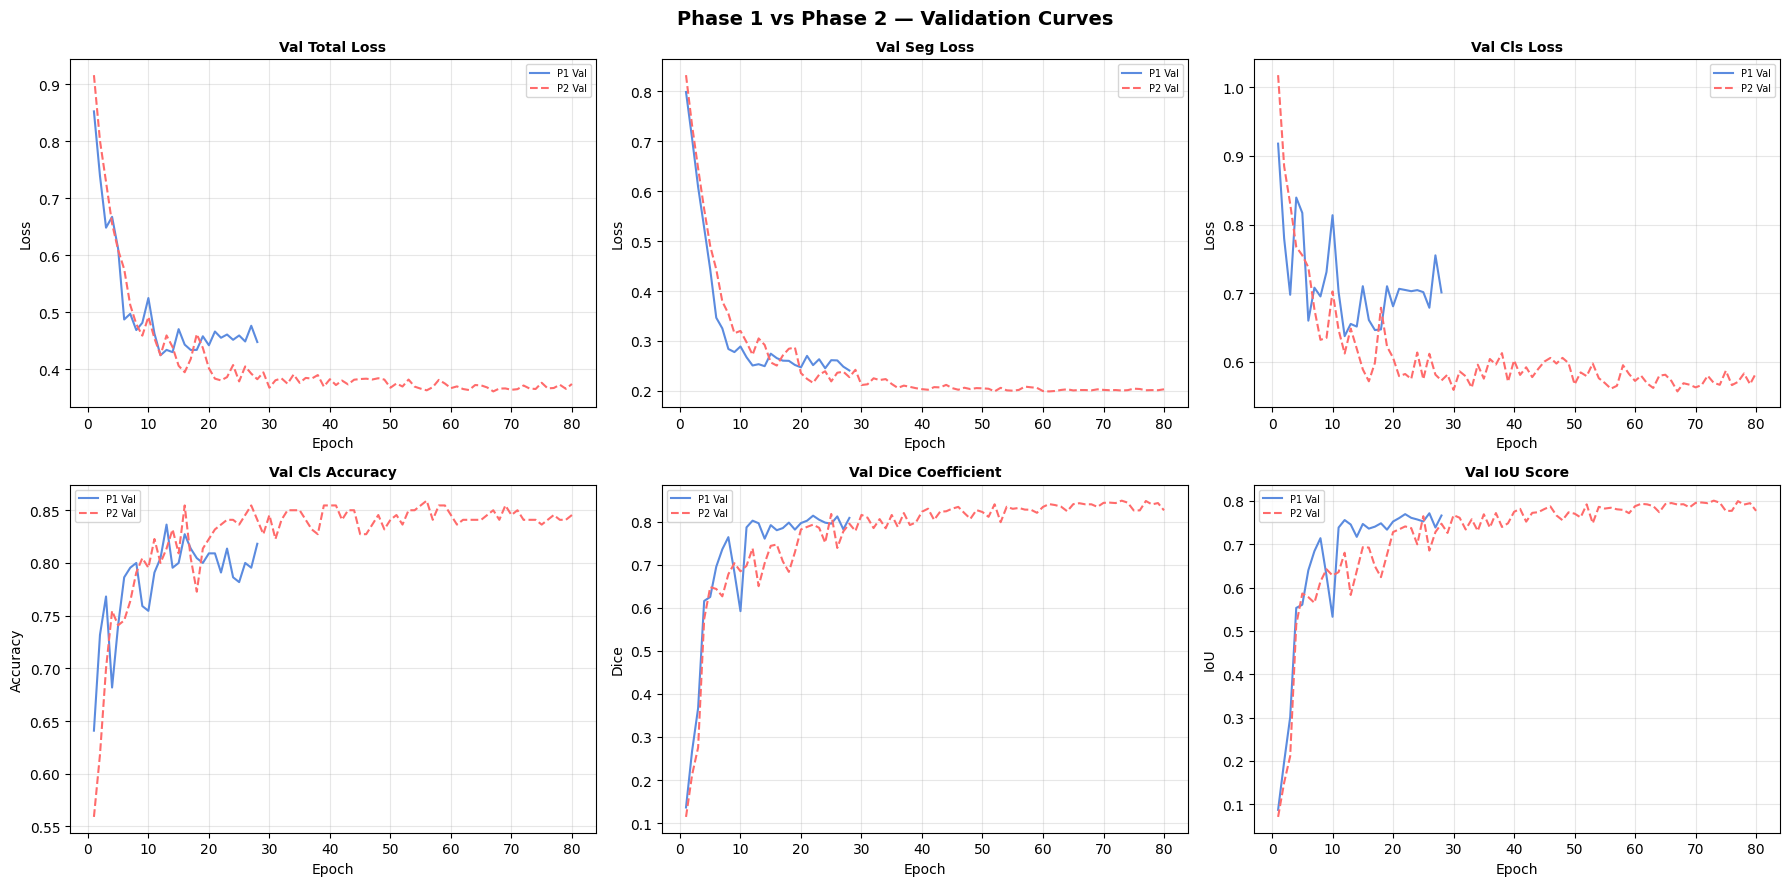


  FINAL SUMMARY  ─  Swin-T UNet Multi-Task Pipeline
  Encoder  : tu-swin_tiny_patch4_window7_224
  Img size : 224×224
  Batch    : 8  (accum=2 → eff=16)
  Params   : 32,696,878  |  Size: 124.7 MB

  [Phase 1 — No Augmentation]
    Cls Accuracy  : 0.8326
    Cls F1 (macro): 0.8181
    Seg Dice      : 0.8112
    Seg IoU       : 0.7572

  [Phase 2 — With Strong Augmentation]
    Cls Accuracy  : 0.8688
    Cls F1 (macro): 0.8503
    Seg Dice      : 0.8482
    Seg IoU       : 0.7950

  Saved output files:
    /kaggle/working/Sample_Images_and_Masks.png
    /kaggle/working/checkpoints/best_Phase1_NoAug.pth
    /kaggle/working/checkpoints/best_Phase2_WithAug.pth
    /kaggle/working/class_distribution.png
    /kaggle/working/comparison_table.csv
    /kaggle/working/confusion_matrix_Phase1_NoAug.png
    /kaggle/working/confusion_matrix_Phase2_WithAug.png
    /kaggle/working/metric_comparison_bars.png
    /kaggle/working/overlay_val_curves.png
    /kaggle/working/qualitative_Phase1_NoAug.png
  

In [26]:
# ============================================================
# CELL 25 — Comparison Table & Overlay Curves & Final Summary
# ============================================================

# ── 1. Comparison Table ──────────────────────────────────────
compare_data = {
    "Metric": [
        # Classification
        "Cls Accuracy", "Cls Precision", "Cls Recall", "Cls F1 (macro)",
        # Segmentation
        "Seg IoU (Jaccard)", "Seg Dice (DSC)", "Seg Pixel Accuracy",
        "Seg Precision", "Seg Recall",
        # Model
        "Total Parameters", "Model Size (MB)",
        "Total Train Time (min)", "Avg Epoch Time (s)",
    ],
    "Phase 1 — No Aug": [
        f"{cls_results_p1['accuracy']:.4f}",
        f"{cls_results_p1['precision']:.4f}",
        f"{cls_results_p1['recall']:.4f}",
        f"{cls_results_p1['f1']:.4f}",
        f"{seg_results_p1['iou']:.4f}",
        f"{seg_results_p1['dice']:.4f}",
        f"{seg_results_p1['pixel_acc']:.4f}",
        f"{seg_results_p1['precision']:.4f}",
        f"{seg_results_p1['recall']:.4f}",
        f"{info_p1['total_params']:,}",
        f"{info_p1['model_size_mb']:.2f}",
        f"{info_p1['total_train_time']/60:.2f}",
        f"{info_p1['avg_epoch_time']:.2f}",
    ],
    "Phase 2 — With Aug": [
        f"{cls_results_p2['accuracy']:.4f}",
        f"{cls_results_p2['precision']:.4f}",
        f"{cls_results_p2['recall']:.4f}",
        f"{cls_results_p2['f1']:.4f}",
        f"{seg_results_p2['iou']:.4f}",
        f"{seg_results_p2['dice']:.4f}",
        f"{seg_results_p2['pixel_acc']:.4f}",
        f"{seg_results_p2['precision']:.4f}",
        f"{seg_results_p2['recall']:.4f}",
        f"{info_p2['total_params']:,}",
        f"{info_p2['model_size_mb']:.2f}",
        f"{info_p2['total_train_time']/60:.2f}",
        f"{info_p2['avg_epoch_time']:.2f}",
    ],
}

df_compare = pd.DataFrame(compare_data)
print("\n" + "="*70)
print("  FULL COMPARISON TABLE")
print("="*70)
print(df_compare.to_string(index=False))
df_compare.to_csv("/kaggle/working/comparison_table.csv", index=False)
print("\n  Saved: /kaggle/working/comparison_table.csv")


# ── 2. Bar Chart: Phase 1 vs Phase 2 (key metrics) ──────────
metrics_to_plot = {
    "Cls Accuracy"  : (cls_results_p1["accuracy"],  cls_results_p2["accuracy"]),
    "Cls F1"        : (cls_results_p1["f1"],         cls_results_p2["f1"]),
    "Seg Dice"      : (seg_results_p1["dice"],       seg_results_p2["dice"]),
    "Seg IoU"       : (seg_results_p1["iou"],        seg_results_p2["iou"]),
    "Seg Pixel Acc" : (seg_results_p1["pixel_acc"],  seg_results_p2["pixel_acc"]),
}

labels  = list(metrics_to_plot.keys())
vals_p1 = [v[0] for v in metrics_to_plot.values()]
vals_p2 = [v[1] for v in metrics_to_plot.values()]

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, vals_p1, width, label="Phase 1 — No Aug",
               color="#5B8BDF", edgecolor="white", linewidth=1.2)
bars2 = ax.bar(x + width/2, vals_p2, width, label="Phase 2 — With Aug",
               color="#FF6B6B", edgecolor="white", linewidth=1.2)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.005,
                f"{h:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_title("Phase 1 vs Phase 2 — Key Metrics Comparison\n"
             "(Model: Swin-T UNet)",
             fontsize=13, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("Score"); ax.set_ylim(0, 1.08)
ax.legend(fontsize=11); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/metric_comparison_bars.png", dpi=150, bbox_inches="tight")
plt.show()


# ── 3. Overlay Training Curves: Phase 1 vs Phase 2 ──────────
def _overlay(ax, key, title, ylabel):
    e1 = range(1, len(history_p1[key]) + 1)
    e2 = range(1, len(history_p2[key]) + 1)
    ax.plot(e1, history_p1[key], lw=1.5, color="#5B8BDF",
            label="P1 Train" if "train" in key else "P1 Val")
    ax.plot(e2, history_p2[key], lw=1.5, color="#FF6B6B",
            label="P2 Train" if "train" in key else "P2 Val", linestyle="--")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_ylabel(ylabel); ax.set_xlabel("Epoch")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
_overlay(axes[0,0], "val_loss",    "Val Total Loss",       "Loss")
_overlay(axes[0,1], "val_seg_loss","Val Seg Loss",         "Loss")
_overlay(axes[0,2], "val_cls_loss","Val Cls Loss",         "Loss")
_overlay(axes[1,0], "val_cls_acc", "Val Cls Accuracy",     "Accuracy")
_overlay(axes[1,1], "val_dice",    "Val Dice Coefficient", "Dice")
_overlay(axes[1,2], "val_iou",     "Val IoU Score",        "IoU")

fig.suptitle("Phase 1 vs Phase 2 — Validation Curves",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/overlay_val_curves.png", dpi=130, bbox_inches="tight")
plt.show()


# ── 4. Final Summary ─────────────────────────────────────────
print("\n" + "="*62)
print("  FINAL SUMMARY  ─  Swin-T UNet Multi-Task Pipeline")
print("="*62)
print(f"  Encoder  : {CFG.ENCODER}")
print(f"  Img size : {CFG.IMG_SIZE}×{CFG.IMG_SIZE}")
print(f"  Batch    : {CFG.BATCH_SIZE}  (accum={CFG.ACCUM_STEPS} → eff={CFG.BATCH_SIZE*CFG.ACCUM_STEPS})")
print(f"  Params   : {info_p1['total_params']:,}  |  Size: {info_p1['model_size_mb']:.1f} MB")
print()
print("  [Phase 1 — No Augmentation]")
print(f"    Cls Accuracy  : {cls_results_p1['accuracy']:.4f}")
print(f"    Cls F1 (macro): {cls_results_p1['f1']:.4f}")
print(f"    Seg Dice      : {seg_results_p1['dice']:.4f}")
print(f"    Seg IoU       : {seg_results_p1['iou']:.4f}")
print()
print("  [Phase 2 — With Strong Augmentation]")
print(f"    Cls Accuracy  : {cls_results_p2['accuracy']:.4f}")
print(f"    Cls F1 (macro): {cls_results_p2['f1']:.4f}")
print(f"    Seg Dice      : {seg_results_p2['dice']:.4f}")
print(f"    Seg IoU       : {seg_results_p2['iou']:.4f}")
print("="*62)

# ── List all saved files ──────────────────────────────────────
saved = sorted(glob.glob("/kaggle/working/*.png") +
               glob.glob("/kaggle/working/*.csv") +
               glob.glob("/kaggle/working/checkpoints/*.pth"))
print("\n  Saved output files:")
for f in saved:
    print(f"    {f}")
